# Применение методов машинного обучения к задаче определения дислексии — Часть 1

**Что исправлено по сравнению с исходным ноутбуком:**
1. **Утечка при undersampling.** Балансировка теперь применяется ТОЛЬКО к train,
   test остаётся в естественном prevalence.
2. **Утечка через подбор порога.** Порог подбирается на val, метрики считаются на test.
3. **GridSearchCV scoring.** `recall` заменён на `f1_macro` / `balanced_accuracy`,
   чтобы не тянуть к тривиальной "всё дислексия".
4. **Random states.** Один сид `SEED=42` пропихнут везде.
5. **Кросс-валидация.** 5-fold по СУБЪЕКТАМ (внешний test) + внутри каждого фолда
   train/val сплит (тоже по субъектам) для подбора порога и early stopping.
6. **Ablation.** Три feature groups: eye-tracking only / socdem only / eye+socdem.
   Это закрывает основной вопрос "вы предсказываете IQ или паттерны чтения?"
7. **Permutation test.** Sanity check: с перемешанными лейблами AUC должен упасть к 0.5.

In [1]:
%pip install catboost -U

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os, re, random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, balanced_accuracy_score,
    confusion_matrix
)
from scipy import stats

SEED = 42

## 1. Общие утилиты

Эти функции переиспользуются всеми моделями (CatBoost, GINE, Transformer, GAT).
Их вынесение в один блок гарантирует, что все модели:
- делают split одинаково и по СУБЪЕКТАМ;
- подбирают порог одинаково и НА VAL, а не на test;
- репортят одинаковый набор метрик;
- имеют один источник rng.

In [25]:
def set_global_seed(seed=SEED):
    """Один сид для всего стека."""
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

In [26]:
def make_subject_cv_splits(subject_ids, labels, n_folds=5, val_frac=0.15, seed=SEED):
    """
    Returns: list из n_folds кортежей (train_subj, val_subj, test_subj).

    Логика:
      - внешний StratifiedKFold по СУБЪЕКТАМ → test;
      - из оставшегося train стратифицированно отрезается val_frac → val;
      - test и val оба содержат только субъектов, которых нет в train.

    Это критично — иначе графы/предложения одного ребёнка попадут в разные сплиты
    (что и было багом исходного ноутбука в GAT).
    """
    subject_ids = np.asarray(subject_ids)
    labels = np.asarray(labels)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    splits = []
    for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(subject_ids, labels)):
        train_full = subject_ids[tr_idx]
        train_lbl = labels[tr_idx]
        # Стратифицированный train/val split по субъектам
        train_subj, val_subj = train_test_split(
            train_full, test_size=val_frac, stratify=train_lbl,
            random_state=seed + fold_idx,
        )
        test_subj = subject_ids[te_idx]
        # Sanity: непересекающиеся
        assert set(train_subj).isdisjoint(val_subj)
        assert set(train_subj).isdisjoint(test_subj)
        assert set(val_subj).isdisjoint(test_subj)
        splits.append((train_subj, val_subj, test_subj))
    return splits

In [27]:
# def pick_threshold(y_true, y_prob, metric='balanced_accuracy', grid=None):
#     """
#     Подбор порога на ВАЛИДАЦИОННОЙ выборке (не на test!).

#     metric: какую метрику максимизировать ('balanced_accuracy' | 'f1' | 'recall').
#     Возвращает float — оптимальный порог.

#     Игнорирует тривиальные пороги (предсказывающие только один класс).
#     """
#     if grid is None:
#         grid = np.linspace(0.05, 0.95, 91)

#     best_score, best_thr = -1.0, 0.5
#     for thr in grid:
#         y_pred = (y_prob >= thr).astype(int)
#         n_pos = int(y_pred.sum())
#         if n_pos == 0 or n_pos == len(y_pred):
#             continue
#         if metric == 'balanced_accuracy':
#             s = balanced_accuracy_score(y_true, y_pred)
#         elif metric == 'f1':
#             s = f1_score(y_true, y_pred, zero_division=0)
#         elif metric == 'recall':
#             s = recall_score(y_true, y_pred, zero_division=0)
#         else:
#             raise ValueError(f"Unknown metric: {metric}")
#         if s > best_score:
#             best_score, best_thr = s, float(thr)
#     return best_thr

In [28]:
def compute_metrics(y_true, y_pred, y_prob=None):
    """
    Возвращает словарь клинически значимых метрик.

    Главные для дислексии:
      - recall_dyslexia (sensitivity) — не пропустили ли больного ребёнка
      - specificity (recall_normal)   — не отправили ли здорового на терапию
      - balanced_acc, f1_macro        — устойчивы к дисбалансу
      - AUC                           — пороговонезависимая
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    m = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'recall_dyslexia': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'specificity':     recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_dyslexia': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_dyslexia':     f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if y_prob is not None and len(np.unique(y_true)) > 1:
        m['auc'] = roc_auc_score(y_true, y_prob)
    else:
        m['auc'] = float('nan')
    m['cm'] = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()
    return m

In [29]:
def aggregate_folds(fold_metrics, keys=None):
    """Mean ± std across folds для каждой ключевой метрики."""
    if keys is None:
        keys = ['accuracy', 'balanced_acc', 'recall_dyslexia', 'specificity',
                'precision_dyslexia', 'f1_dyslexia', 'f1_macro', 'auc']
    summary = {}
    for k in keys:
        vals = [m[k] for m in fold_metrics
                if k in m and m[k] is not None and not (isinstance(m[k], float) and np.isnan(m[k]))]
        if vals:
            summary[k] = (float(np.mean(vals)), float(np.std(vals)))
    return summary


def print_cv_summary(summary, title="CV Summary"):
    print(f"\n=== {title} ===")
    for k, (mean, std) in summary.items():
        print(f"  {k:22s}: {mean:.4f} ± {std:.4f}")

In [30]:
def pick_threshold(y_true, y_prob, metric='balanced_accuracy', grid=None, verbose=False):
    """
    Подбор порога на val. Адаптивный grid: equidistant + quantile-based.

    metric: 'balanced_accuracy' | 'f1' | 'recall'.
    Возвращает float — лучший порог (или median(y_prob) если все тривиальны).
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if grid is None:
        if len(y_prob) >= 5 and np.unique(y_prob).size >= 5:
            # Equidistant + quantile-based — покрывает любое распределение probs
            equi = np.linspace(0.0, 1.0, 51)
            quant = np.quantile(y_prob, np.linspace(0.02, 0.98, 25))
            grid = np.unique(np.concatenate([equi, quant]))
        else:
            grid = np.linspace(0.05, 0.95, 19)

    best_score, best_thr = -1.0, None
    for thr in grid:
        y_pred = (y_prob >= thr).astype(int)
        n_pos = int(y_pred.sum())
        if n_pos == 0 or n_pos == len(y_pred):
            continue
        if metric == 'balanced_accuracy':
            s = balanced_accuracy_score(y_true, y_pred)
        elif metric == 'f1':
            s = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            s = recall_score(y_true, y_pred, zero_division=0)
        else:
            raise ValueError(f"Unknown metric: {metric}")
        if s > best_score:
            best_score, best_thr = s, float(thr)

    if best_thr is None:
        # Fallback: все пороги тривиальны (вырожденный случай)
        best_thr = float(np.median(y_prob))
        if verbose:
            print(f"  [pick_threshold] WARNING: all grid thresholds trivial, "
                  f"falling back to median(y_prob)={best_thr:.4f}")
    elif verbose:
        # Diagnostic: насколько скошен y_prob и насколько необычный thr
        q05, q95 = np.quantile(y_prob, [0.05, 0.95])
        if best_thr < q05 or best_thr > q95:
            print(f"  [pick_threshold] note: chosen thr={best_thr:.3f} is outside "
                  f"[q05={q05:.3f}, q95={q95:.3f}] — model probabilities are skewed")

    return best_thr

## 2. Загрузка и подготовка данных

In [31]:
FIX_PATH = '/home/jupyter/project/Fixation_report_dyslexia.xlsx'
DEMO_PATH = '/home/jupyter/project/demo_groups.xlsx'

def load_data(fix_path=FIX_PATH, demo_path=DEMO_PATH):
    # Демография: листы dyslexia / norm; risk пока игнорируем — нужна явная позиция
    # (это binary classification: dyslexia vs norm).
    dys = pd.read_excel(demo_path, sheet_name='dyslexia')
    nrm = pd.read_excel(demo_path, sheet_name='norm')
    def _sex_to_int(x):
        # 1 = female, 0 = male
        return 1 if str(x).lower() in ('fem', 'female', 'f') else 0
    nrm['Sex'] = nrm['Sex'].apply(_sex_to_int)
    dys['Sex'] = dys['Sex'].apply(_sex_to_int)
    dys['label'] = 1
    nrm['label'] = 0
    labels = pd.concat([dys, nrm], ignore_index=True)
    labels = labels.rename(columns={'SubjID': 'SubjectID'})
    labels = labels[['SubjectID', 'label', 'Sex', 'Age', 'IQ', 'Grade']]

    # Фиксации
    fix = pd.read_excel(fix_path, sheet_name='data')
    # Унификация: точки vместо запятых, если числа пришли строками
    for col in ['FIX_X', 'FIX_Y', 'FIX_DURATION']:
        if fix[col].dtype == object:
            fix[col] = fix[col].astype(str).str.replace(',', '.').astype(float)

    # Оставляем только субъектов, для которых есть и фиксации, и лейблы
    common = set(fix['SubjectID']) & set(labels['SubjectID'])
    fix = fix[fix['SubjectID'].isin(common)].reset_index(drop=True)
    labels = labels[labels['SubjectID'].isin(common)].reset_index(drop=True)

    # Стабильный порядок (если есть Order/index — отсортируйся; здесь полагаемся
    # на исходный порядок строк, см. примечание ниже)
    print(f"Subjects: {len(labels)} (pos={labels['label'].sum()}, neg={(labels['label']==0).sum()})")
    print(f"Fixations: {len(fix):,}, sentences: {fix['Sentence_ID'].nunique()}")
    return fix, labels


## 3. Извлечение признаков (subject-level)

Сначала агрегируем по парам (subject, sentence), потом по subject.
Признаки:
- **Eye-tracking:** длительность фиксаций, число фиксаций, саккады, регрессии,
  scan_regularity, time_per_word — статистики mean/std/max/min по предложениям.
- **Socdem:** Age, Sex, IQ, Grade.
Ablation проводим по группам признаков.

In [32]:
def compute_sentence_level(fix):
    """Признаки для каждой пары (subject, sentence)."""
    rows = []
    for (subj, sent), g in fix.groupby(['SubjectID', 'Sentence_ID'], sort=False):
        if len(g) < 2:
            continue
        x = g['FIX_X'].values
        y = g['FIX_Y'].values
        d = g['FIX_DURATION'].values
        words = g['Word_Number'].values

        dx = np.diff(x)
        dy = np.diff(y)
        sacc = np.sqrt(dx**2 + dy**2)
        regs = int((dx < 0).sum())

        # Scan regularity = корреляция позиции в последовательности с FIX_X
        if np.unique(x).size > 1:
            sr = float(np.corrcoef(np.arange(len(x)), x)[0, 1])
        else:
            sr = 0.0
        n_words = int(np.max(words)) if len(words) else 1

        rows.append({
            'SubjectID': subj, 'Sentence_ID': sent,
            'fix_count': len(g),
            'total_duration': float(d.sum()),
            'mean_fix_duration': float(d.mean()),
            'std_fix_duration': float(d.std(ddof=0)),
            'mean_saccade_amp': float(sacc.mean()) if len(sacc) else 0.0,
            'max_saccade_amp': float(sacc.max()) if len(sacc) else 0.0,
            'regression_count': regs,
            'regression_ratio': regs / max(1, len(dx)),
            'scan_regularity': sr if not np.isnan(sr) else 0.0,
            'time_per_word': float(d.sum() / max(1, n_words)),
        })
    return pd.DataFrame(rows)


def compute_subject_level(sentence_df, labels):
    """Агрегация sentence-level признаков на уровень субъекта + socdem."""
    metric_cols = [c for c in sentence_df.columns if c not in ('SubjectID', 'Sentence_ID')]
    agg = sentence_df.groupby('SubjectID')[metric_cols].agg(['mean', 'std', 'max', 'min'])
    agg.columns = [f'{a}_{b}' for a, b in agg.columns]
    agg = agg.reset_index()
    out = agg.merge(labels, on='SubjectID', how='inner')
    return out

## 4. Главная функция: CV + ablation

Запускает один эксперимент с заданной группой признаков.
Для каждого фолда:
  1. сплит по субъектам train / val / test (val вырезан из train);
  2. обучение CatBoost с early stopping на val;
  3. подбор порога на val;
  4. оценка на test;
В конце — агрегирование по фолдам.

In [33]:
def run_catboost_cv(features_df, feature_cols, n_folds=5, seed=SEED,
                    threshold_metric='balanced_accuracy', verbose=True):
    """
    features_df: DataFrame с колонками SubjectID, label, и фичами.
    feature_cols: список колонок-фичей для этого запуска.
    """
    set_global_seed(seed)

    subj_ids = features_df['SubjectID'].values
    y_all = features_df['label'].values

    splits = make_subject_cv_splits(subj_ids, y_all, n_folds=n_folds, seed=seed)
    fold_metrics = []

    for fold_i, (train_subj, val_subj, test_subj) in enumerate(splits, 1):
        train = features_df[features_df['SubjectID'].isin(train_subj)]
        val   = features_df[features_df['SubjectID'].isin(val_subj)]
        test  = features_df[features_df['SubjectID'].isin(test_subj)]

        X_tr, y_tr = train[feature_cols], train['label']
        X_va, y_va = val[feature_cols],   val['label']
        X_te, y_te = test[feature_cols],  test['label']

        # Class weights считаем ТОЛЬКО по train (никаких подсматриваний в val/test)
        n_neg = int((y_tr == 0).sum())
        n_pos = int((y_tr == 1).sum())
        pos_w = n_neg / max(n_pos, 1)

        model = CatBoostClassifier(
            class_weights=[1.0, pos_w],
            iterations=2000,
            learning_rate=0.03,
            depth=6,
            loss_function='Logloss',
            eval_metric='AUC',
            early_stopping_rounds=100,
            random_seed=seed,
            verbose=0,
        )
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)

        # Порог — на ВАЛ
        val_prob = model.predict_proba(X_va)[:, 1]
        best_thr = pick_threshold(y_va.values, val_prob, metric=threshold_metric)

        # Метрики — на TEST (с порогом, выбранным на val)
        test_prob = model.predict_proba(X_te)[:, 1]
        test_pred = (test_prob >= best_thr).astype(int)
        m = compute_metrics(y_te.values, test_pred, test_prob)
        m['threshold'] = best_thr
        m['n_train'] = int(len(train_subj))
        m['n_val']   = int(len(val_subj))
        m['n_test']  = int(len(test_subj))
        m['y_test_true'] = np.asarray(y_te).astype(int)
        m['y_test_prob'] = np.asarray(test_prob, dtype=float)
        fold_metrics.append(m)

        if verbose:
            print(f"  fold {fold_i}: "
                  f"bal_acc={m['balanced_acc']:.3f}  "
                  f"recall_dys={m['recall_dyslexia']:.3f}  "
                  f"spec={m['specificity']:.3f}  "
                  f"f1_macro={m['f1_macro']:.3f}  "
                  f"AUC={m['auc']:.3f}  thr={best_thr:.2f}")

    summary = aggregate_folds(fold_metrics)
    return {'folds': fold_metrics, 'summary': summary}

## 5. Запуск ablation

Три feature groups:
- **eye:** только eye-tracking признаки.
- **demo:** только Age, Sex, IQ, Grade.
- **all:** eye + demo.

Если "demo" даёт почти такой же результат, как "all" — значит eye-tracking
мало добавляет, и модель скорее всего просто эксплуатирует разницу в IQ.
Это первый вопрос рецензента.

In [34]:
def run_ablation(features_df, n_folds=5, seed=SEED):
    eye_cols = [c for c in features_df.columns
                if c not in ('SubjectID', 'label', 'Age', 'Sex', 'IQ', 'Grade')]
    demo_cols = ['Age', 'Sex', 'IQ', 'Grade']
    feature_groups = {
        'eye':  eye_cols,
        'demo': demo_cols,
        'all':  eye_cols + demo_cols,
    }
    all_results = {}
    for name, cols in feature_groups.items():
        print(f"\n========== Feature group: {name} ({len(cols)} features) ==========")
        res = run_catboost_cv(features_df, cols, n_folds=n_folds, seed=seed)
        print_cv_summary(res['summary'], title=f"CatBoost CV — group: {name}")
        all_results[name] = res
    return all_results

## 6. Permutation test — sanity check

Перемешиваем лейблы и запускаем тот же пайплайн. Ожидаемое поведение:
AUC ≈ 0.5, balanced_acc ≈ 0.5. Если на перемешанных данных модель показывает
что-то осмысленное — где-то остаётся утечка.

In [35]:
def permutation_test(features_df, feature_cols, n_perm=10, n_folds=5, seed=SEED):
    rng = np.random.RandomState(seed)
    perm_results = []
    for p in range(n_perm):
        df_perm = features_df.copy()
        df_perm['label'] = rng.permutation(df_perm['label'].values)
        res = run_catboost_cv(df_perm, feature_cols, n_folds=n_folds,
                              seed=seed + p, verbose=False)
        auc_mean = res['summary'].get('auc', (float('nan'),))[0]
        bal_mean = res['summary'].get('balanced_acc', (float('nan'),))[0]
        perm_results.append({'perm': p, 'auc': auc_mean, 'bal_acc': bal_mean})
        print(f"  perm {p+1}/{n_perm}: AUC={auc_mean:.3f}  bal_acc={bal_mean:.3f}")
    return pd.DataFrame(perm_results)

## 7. Стат-тест на различия групп (для EDA-секции пейпера)

In [36]:
def group_difference_tests(features_df, feature_cols):
    """
    Для каждой фичи: Mann-Whitney U test (непараметрический, не предполагает
    нормальности). Корректировка на multiple testing — Benjamini-Hochberg FDR.
    """
    pos = features_df[features_df['label'] == 1]
    neg = features_df[features_df['label'] == 0]
    rows = []
    for c in feature_cols:
        a = pos[c].dropna().values
        b = neg[c].dropna().values
        if len(a) < 3 or len(b) < 3:
            continue
        # Skip non-numeric / constant
        if not np.issubdtype(a.dtype, np.number) or np.unique(np.concatenate([a, b])).size < 2:
            continue
        try:
            stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        except ValueError:
            stat, p = np.nan, np.nan
        rows.append({
            'feature': c,
            'mean_dys': float(np.mean(a)),
            'mean_norm': float(np.mean(b)),
            'U': float(stat) if not np.isnan(stat) else np.nan,
            'p_raw': float(p) if not np.isnan(p) else np.nan,
        })
    df = pd.DataFrame(rows).sort_values('p_raw')
    # Benjamini-Hochberg FDR
    df = df.dropna(subset=['p_raw']).reset_index(drop=True)
    n = len(df)
    df['p_bh'] = df['p_raw'] * n / (df.index + 1)
    # Монотонизация снизу-вверх
    df['p_bh'] = df['p_bh'][::-1].cummin()[::-1].clip(upper=1.0)
    df['sig_bh_0.05'] = df['p_bh'] < 0.05
    return df

## 8. Запуск всего пайплайна



In [23]:
fix, labels = load_data()
sent_df = compute_sentence_level(fix)
subj_df = compute_subject_level(sent_df, labels)
print(f"Subject-level dataset: {subj_df.shape}")
subj_df.head()

Subjects: 261 (pos=72, neg=189)
Fixations: 180,513, sentences: 30
Subject-level dataset: (261, 46)


,SubjectID,fix_count_mean,fix_count_std,fix_count_max,fix_count_min,total_duration_mean,total_duration_std,total_duration_max,total_duration_min,mean_fix_duration_mean,mean_fix_duration_std,mean_fix_duration_max,mean_fix_duration_min,std_fix_duration_mean,std_fix_duration_std,std_fix_duration_max,std_fix_duration_min,mean_saccade_amp_mean,mean_saccade_amp_std,mean_saccade_amp_max,mean_saccade_amp_min,max_saccade_amp_mean,max_saccade_amp_std,max_saccade_amp_max,max_saccade_amp_min,regression_count_mean,regression_count_std,regression_count_max,regression_count_min,regression_ratio_mean,regression_ratio_std,regression_ratio_max,regression_ratio_min,scan_regularity_mean,scan_regularity_std,scan_regularity_max,scan_regularity_min,time_per_word_mean,time_per_word_std,time_per_word_max,time_per_word_min,label,Sex,Age,IQ,Grade
0,2,9.433333,3.036370,21,5,1467.066667,485.980412,2721.0,974.0,159.923208,41.430798,275.800000,93.500000,76.712844,43.754454,226.494503,28.201655,156.897208,27.937775,241.058145,107.252437,340.065532,152.106898,751.360433,187.771617,1.666667,1.212957,5,0,0.183112,0.108848,0.333333,0.000000,0.819756,0.251789,0.994972,0.078459,201.898042,68.239863,388.714286,123.625,0,0,10,34,4
1,3,25.000000,8.901763,42,12,2814.933333,1058.131761,5756.0,1519.0,115.106455,24.380467,182.625000,75.200000,66.821988,25.095752,164.894616,44.779361,75.600016,26.834406,184.307058,43.307897,298.948140,201.302270,1014.808750,142.018485,6.733333,3.795945,14,0,0.260373,0.090469,0.400000,0.000000,0.824605,0.253749,0.993634,0.028846,374.787765,143.828565,822.285714,193.750,0,0,10,36,4
2,4,18.166667,3.705386,26,11,2111.366667,521.252238,3108.0,1235.0,117.878023,26.323828,174.600000,77.187500,59.976900,10.768756,85.013465,36.530767,109.740942,28.705051,194.158317,63.104840,329.188477,175.698333,849.547674,174.198622,6.100000,2.482351,14,3,0.351349,0.099281,0.666667,0.176471,0.821143,0.229821,0.981536,0.205560,284.469312,69.217528,431.142857,168.875,0,1,10,33,4
3,6,19.633333,5.886767,36,8,3836.700000,1080.246305,5971.0,2277.0,199.631303,30.960462,284.625000,137.000000,102.334462,22.924499,173.664440,63.208795,97.686176,24.149133,149.225989,56.713789,342.187238,214.982297,832.648029,146.250778,6.000000,3.096160,13,0,0.303687,0.112905,0.480000,0.000000,0.817368,0.204352,0.995493,0.392512,511.645833,135.443116,787.000000,284.625,0,1,9,33,4
4,9,21.700000,6.858923,43,12,3664.833333,1267.256012,7627.0,2064.0,169.177901,22.376263,215.833333,125.571429,80.658520,22.595775,148.831067,49.562811,88.942039,25.385938,151.478046,58.348908,386.087698,262.657603,977.802045,152.630076,6.100000,3.707867,18,0,0.277604,0.103815,0.437500,0.000000,0.751223,0.283497,0.988793,0.119732,490.297817,179.483579,1089.571429,258.000,0,1,10,29,4


In [17]:
# --- Стат-тесты для EDA ---
eye_cols_for_test = [c for c in subj_df.columns
                     if c not in ('SubjectID', 'label', 'Age', 'Sex', 'IQ', 'Grade')]
diff_df = group_difference_tests(subj_df, eye_cols_for_test + ['Age', 'IQ', 'Grade'])
print(diff_df.head(20))

                   feature      mean_dys  ...          p_bh  sig_bh_0.05
0       time_per_word_mean   1336.308782  ...  4.768662e-17         True
1      total_duration_mean   9798.186986  ...  1.150927e-16         True
2   mean_fix_duration_mean    330.058733  ...  9.322180e-16         True
3        time_per_word_std    539.705502  ...  2.880729e-15         True
4        time_per_word_max   2750.794037  ...  6.115414e-15         True
5    mean_fix_duration_min    244.003141  ...  7.000263e-15         True
6       total_duration_std   3825.138413  ...  7.000263e-15         True
7       total_duration_max  19632.277778  ...  1.523557e-14         True
8     std_fix_duration_min     91.377587  ...  5.440177e-13         True
9      max_saccade_amp_min    100.275534  ...  2.676491e-12         True
10    mean_saccade_amp_min     45.955655  ...  2.676491e-12         True
11   std_fix_duration_mean    168.875712  ...  2.676491e-12         True
12   mean_fix_duration_max    429.053856  ...  2.71

In [76]:
# --- Ablation ---
results = run_ablation(subj_df, n_folds=5, seed=SEED)


========== Feature group: eye (40 features) ==========
  fold 1: bal_acc=0.754  recall_dys=0.533  spec=0.974  f1_macro=0.785  AUC=0.918  thr=0.61
  fold 2: bal_acc=0.780  recall_dys=0.929  spec=0.632  f1_macro=0.698  AUC=0.912  thr=0.38
  fold 3: bal_acc=0.758  recall_dys=0.857  spec=0.658  f1_macro=0.692  AUC=0.793  thr=0.28
  fold 4: bal_acc=0.829  recall_dys=1.000  spec=0.658  f1_macro=0.738  AUC=0.932  thr=0.41
  fold 5: bal_acc=0.672  recall_dys=0.533  spec=0.811  f1_macro=0.672  AUC=0.804  thr=0.51

=== CatBoost CV — group: eye ===
  accuracy              : 0.7506 ± 0.0513
  balanced_acc          : 0.7584 ± 0.0508
  recall_dyslexia       : 0.7705 ± 0.1988
  specificity           : 0.7464 ± 0.1301
  precision_dyslexia    : 0.5804 ± 0.1556
  f1_dyslexia           : 0.6265 ± 0.0523
  f1_macro              : 0.7170 ± 0.0400
  auc                   : 0.8717 ± 0.0603

========== Feature group: demo (4 features) ==========
  fold 1: bal_acc=0.710  recall_dys=0.867  spec=0.553  f1_macro

In [63]:
# --- Permutation test (на all-features) ---
eye_cols  = [c for c in subj_df.columns
             if c not in ('SubjectID', 'label', 'Age', 'Sex', 'IQ', 'Grade')]
demo_cols = ['Age', 'Sex', 'IQ', 'Grade']
perm_df = permutation_test(subj_df, eye_cols + demo_cols, n_perm=10, n_folds=5)
print("\nPermutation test summary:")
print(perm_df.describe())

  perm 1/10: AUC=0.475  bal_acc=0.488
  perm 2/10: AUC=0.405  bal_acc=0.428
  perm 3/10: AUC=0.559  bal_acc=0.516
  perm 4/10: AUC=0.523  bal_acc=0.517
  perm 5/10: AUC=0.526  bal_acc=0.537
  perm 6/10: AUC=0.472  bal_acc=0.496
  perm 7/10: AUC=0.444  bal_acc=0.465
  perm 8/10: AUC=0.540  bal_acc=0.530
  perm 9/10: AUC=0.545  bal_acc=0.547
  perm 10/10: AUC=0.507  bal_acc=0.487

Permutation test summary:
           perm        auc    bal_acc
count  10.00000  10.000000  10.000000
mean    4.50000   0.499720   0.501034
std     3.02765   0.049445   0.036138
min     0.00000   0.405056   0.428273
25%     2.25000   0.472432   0.487213
50%     4.50000   0.515227   0.505533
75%     6.75000   0.536523   0.526781
max     9.00000   0.559244   0.547480


In [20]:
# --- Итоговая табличка для пейпера ---
rows = []
for grp, res in results.items():
    for k, (m, s) in res['summary'].items():
        rows.append({'group': grp, 'metric': k, 'mean': m, 'std': s})
table = pd.DataFrame(rows).pivot(index='metric', columns='group', values=['mean', 'std'])
print(table)

                        mean                           std                    
group                    all      demo       eye       all      demo       eye
metric                                                                        
accuracy            0.781205  0.582148  0.750581  0.102640  0.064879  0.051262
auc                 0.889532  0.629324  0.871673  0.063464  0.074230  0.060280
balanced_acc        0.785166  0.627307  0.758424  0.053393  0.070795  0.050841
f1_dyslexia         0.679944  0.487981  0.626492  0.078640  0.078654  0.052267
f1_macro            0.752918  0.563499  0.717049  0.089482  0.059607  0.040012
precision_dyslexia  0.647121  0.371251  0.580444  0.177956  0.059682  0.155612
recall_dyslexia     0.792381  0.731429  0.770476  0.133761  0.168024  0.198826
specificity         0.777952  0.523186  0.746373  0.177197  0.105945  0.130121


In [24]:
%pip install torch_geometric -q


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [25]:
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.metrics import roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Построение графов word-level

- Узлы = слова в предложении (длина L);
- признаки узла: fix_count, log(total_duration), log(mean_duration), std_duration,
  log(first_pass_duration), нормированная позиция слова в предложении (6 фичей);
- рёбра = саккады между фиксациями (dx, dy, amp, is_regression);
- один граф = одна пара (subject, sentence).

In [26]:
def _count_words_ru(text):
    return len(re.findall(r"[A-Za-zА-Яа-яЁё0-9]+", str(text)))


def load_sentence_lengths(fix_path):
    """
    Достаёт словарь {sentence_id: word_count}.

    NB: лист 'Предложения' в исходных данных может приходить с битым заголовком
    (когда первая строка — это сама первая фраза). Здесь делаем явный
    fallback: если ожидаемых колонок нет, переименовываем по позиции.
    """
    sent = pd.read_excel(fix_path, sheet_name='Предложения')
    if 'sentence' not in sent.columns or 'number' not in sent.columns:
        # Битый header — предполагаем порядок [number, sentence]
        sent = sent.reset_index(drop=True)
        sent.columns = ['number', 'sentence']
    sent['number'] = sent['number'].astype(int)
    sent['word_count'] = sent['sentence'].apply(_count_words_ru)
    return dict(zip(sent['number'], sent['word_count']))


def build_word_graph_one(df_ss, L):
    """Один граф для пары (subject, sentence). L — число слов в предложении."""
    node_fix_count = np.zeros(L, dtype=np.float32)
    node_total_dur = np.zeros(L, dtype=np.float32)
    node_mean_dur  = np.zeros(L, dtype=np.float32)
    node_std_dur   = np.zeros(L, dtype=np.float32)
    node_firstpass = np.zeros(L, dtype=np.float32)

    for w in range(1, L + 1):
        g = df_ss[df_ss['Word_Number'] == w]
        if len(g) == 0:
            continue
        idx = w - 1
        node_fix_count[idx] = len(g)
        node_total_dur[idx] = g['FIX_DURATION'].sum()
        node_mean_dur[idx]  = g['FIX_DURATION'].mean()
        node_std_dur[idx]   = g['FIX_DURATION'].std(ddof=0) if len(g) > 1 else 0.0
        node_firstpass[idx] = float(g.iloc[0]['FIX_DURATION'])

    word_pos = np.linspace(0, 1, L, dtype=np.float32)
    x = np.stack([
        node_fix_count,
        np.log1p(node_total_dur),
        np.log1p(node_mean_dur),
        node_std_dur,
        np.log1p(node_firstpass),
        word_pos,
    ], axis=1).astype(np.float32)

    words = df_ss['Word_Number'].to_numpy().astype(int)
    xs = df_ss['FIX_X'].to_numpy().astype(np.float32)
    ys = df_ss['FIX_Y'].to_numpy().astype(np.float32)

    edge_src, edge_dst, edge_attr = [], [], []
    for i in range(len(df_ss) - 1):
        a = int(words[i]) - 1
        b = int(words[i + 1]) - 1
        if not (0 <= a < L and 0 <= b < L):
            continue
        dx = float(xs[i + 1] - xs[i])
        dy = float(ys[i + 1] - ys[i])
        amp = float(np.sqrt(dx * dx + dy * dy))
        is_reg = 1.0 if (b < a) else 0.0
        edge_src.append(a)
        edge_dst.append(b)
        edge_attr.append([dx, dy, amp, is_reg])

    if len(edge_src) == 0:
        return None

    return Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=torch.tensor(np.stack([edge_src, edge_dst], axis=0), dtype=torch.long),
        edge_attr=torch.tensor(np.array(edge_attr, dtype=np.float32), dtype=torch.float),
    )


def build_word_graphs(fix, labels, sent_len):
    """
    Возвращает список графов; у каждого есть:
      - y       (метка, float, форма [1])
      - subj_idx (числовой ID субъекта, long, форма [1]) — нужен для batching;
        строковый id восстанавливается через idx_to_subj.
    """
    lbl_map = dict(zip(labels['SubjectID'], labels['label']))
    unique_subj = list(labels['SubjectID'].unique())
    subj_to_idx = {s: i for i, s in enumerate(unique_subj)}
    idx_to_subj = {i: s for s, i in subj_to_idx.items()}

    graphs = []
    skipped = 0
    for (subj, sid), df_ss in fix.groupby(['SubjectID', 'Sentence_ID'], sort=False):
        if subj not in lbl_map:
            skipped += 1
            continue
        sid_int = int(sid)
        if sid_int not in sent_len:
            skipped += 1
            continue
        L = int(sent_len[sid_int])
        if L <= 0:
            skipped += 1
            continue
        g = build_word_graph_one(df_ss, L)
        if g is None:
            skipped += 1
            continue
        g.y = torch.tensor([float(lbl_map[subj])], dtype=torch.float)
        g.subj_idx = torch.tensor([subj_to_idx[subj]], dtype=torch.long)
        g.sentence_id = sid_int
        graphs.append(g)
    print(f"Built {len(graphs)} graphs (skipped {skipped})")
    return graphs, subj_to_idx, idx_to_subj

## Модель GINEClassifier

In [27]:
class GINEClassifier(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.node_enc = nn.Linear(in_dim, hidden)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
            )
            self.convs.append(GINEConv(nn=mlp, edge_dim=edge_dim))
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.node_enc(x)
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        g = global_mean_pool(x, batch)
        return self.head(g).squeeze(-1)

## 3. Eval на уровне субъекта

Для каждого ребёнка усредняем предсказанные вероятности по его предложениям —
одна метка на ребёнка.

In [28]:
@torch.no_grad()
def eval_subject_level(model, loader, device):
    model.eval()
    subj_probs = defaultdict(list)
    subj_y = {}
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        # batch.subj_idx — long tensor длины n_graphs_in_batch
        idxs = batch.subj_idx.cpu().numpy().astype(int)
        ys = batch.y.cpu().numpy().astype(int)
        for i in range(len(probs)):
            sid = int(idxs[i])
            subj_probs[sid].append(float(probs[i]))
            subj_y[sid] = int(ys[i])
    sorted_subj = sorted(subj_y.keys())
    y_true = np.array([subj_y[s] for s in sorted_subj], dtype=int)
    y_prob = np.array([np.mean(subj_probs[s]) for s in sorted_subj], dtype=float)
    return y_true, y_prob

## 4. Один фолд: train + early stopping по val + eval на test

In [29]:
def train_gine_one_fold(train_graphs, val_graphs, test_graphs,
                        epochs=60, patience=15, batch_size=64,
                        lr=1e-3, weight_decay=1e-4, seed=SEED, verbose=False):
    set_global_seed(seed)

    train_loader = PyGDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader   = PyGDataLoader(val_graphs,   batch_size=batch_size, shuffle=False)
    test_loader  = PyGDataLoader(test_graphs,  batch_size=batch_size, shuffle=False)

    # pos_weight считается ТОЛЬКО по train
    y_tr = np.array([int(g.y.item()) for g in train_graphs])
    n_pos = int((y_tr == 1).sum())
    n_neg = int((y_tr == 0).sum())
    pos_w = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float, device=device)

    in_dim = train_graphs[0].x.size(1)
    edge_dim = train_graphs[0].edge_attr.size(1)

    model = GINEClassifier(in_dim=in_dim, edge_dim=edge_dim,
                           hidden=64, num_layers=3, dropout=0.2).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    best_val_auc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            opt.step()
            total_loss += float(loss.item())

        # Eval on VAL (никогда не на test внутри цикла)
        y_v, p_v = eval_subject_level(model, val_loader, device)
        val_auc = roc_auc_score(y_v, p_v) if len(np.unique(y_v)) > 1 else float('nan')

        if not np.isnan(val_auc) and val_auc > best_val_auc + 1e-9:
            best_val_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"    epoch {epoch:03d}: loss={total_loss/len(train_loader):.3f} "
                  f"val_auc={val_auc:.3f} best_val_auc={best_val_auc:.3f}")

        if no_improve >= patience:
            print(f"    early stop at epoch {epoch} (best val AUC={best_val_auc:.3f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Порог — на VAL
    y_v, p_v = eval_subject_level(model, val_loader, device)
    best_thr = pick_threshold(y_v, p_v, metric='balanced_accuracy')

    # Метрики — на TEST с этим порогом
    y_te, p_te = eval_subject_level(model, test_loader, device)
    y_te_pred = (p_te >= best_thr).astype(int)
    m = compute_metrics(y_te, y_te_pred, p_te)
    m['threshold'] = float(best_thr)
    m['best_val_auc'] = float(best_val_auc)
    m['y_test_true'] = np.asarray(y_te).astype(int)
    m['y_test_prob'] = np.asarray(p_te, dtype=float)
    return m

## 5. CV runner для GINE

In [30]:
def run_gine_cv(fix, labels, sent_len, n_folds=5, epochs=60, patience=15,
                batch_size=64, seed=SEED):
    set_global_seed(seed)

    print("Building graphs...")
    all_graphs, subj_to_idx, idx_to_subj = build_word_graphs(fix, labels, sent_len)

    # Соответствие subject → индексы его графов
    subj_to_graph_idx = defaultdict(list)
    for i, g in enumerate(all_graphs):
        sid = int(g.subj_idx.item())
        subj_to_graph_idx[sid].append(i)

    # Субъекты с хотя бы одним графом
    subj_ids_with_data = [s for s in labels['SubjectID']
                          if subj_to_idx.get(s) in subj_to_graph_idx]
    lbl_map = dict(zip(labels['SubjectID'], labels['label']))
    subj_labels = np.array([lbl_map[s] for s in subj_ids_with_data])
    subj_idx_arr = np.array([subj_to_idx[s] for s in subj_ids_with_data])

    print(f"Subjects with graphs: {len(subj_ids_with_data)} "
          f"(pos={int(subj_labels.sum())}, neg={int((subj_labels==0).sum())})")

    splits = make_subject_cv_splits(subj_idx_arr, subj_labels, n_folds=n_folds, seed=seed)
    fold_metrics = []

    for fold_i, (train_idx, val_idx, test_idx) in enumerate(splits, 1):
        print(f"\n--- Fold {fold_i}/{n_folds} ---")
        print(f"  Subjects: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

        train_graphs = [all_graphs[i] for s in train_idx for i in subj_to_graph_idx[int(s)]]
        val_graphs   = [all_graphs[i] for s in val_idx   for i in subj_to_graph_idx[int(s)]]
        test_graphs  = [all_graphs[i] for s in test_idx  for i in subj_to_graph_idx[int(s)]]
        print(f"  Graphs:   train={len(train_graphs)}, val={len(val_graphs)}, test={len(test_graphs)}")

        m = train_gine_one_fold(
            train_graphs, val_graphs, test_graphs,
            epochs=epochs, patience=patience, batch_size=batch_size,
            seed=seed + fold_i,  # разные сиды для разных фолдов
            verbose=False,
        )
        fold_metrics.append(m)
        print(f"  fold {fold_i}: bal_acc={m['balanced_acc']:.3f}  "
              f"recall_dys={m['recall_dyslexia']:.3f}  "
              f"spec={m['specificity']:.3f}  f1_macro={m['f1_macro']:.3f}  "
              f"AUC={m['auc']:.3f}  thr={m['threshold']:.2f}")

    summary = aggregate_folds(fold_metrics)
    return {'folds': fold_metrics, 'summary': summary}

In [57]:
sent_len = load_sentence_lengths(FIX_PATH)

In [78]:
sent_len = load_sentence_lengths(FIX_PATH)
gine_results = run_gine_cv(
    fix, labels, sent_len,
    n_folds=5, epochs=60, patience=15, batch_size=64, seed=SEED,
)
print_cv_summary(gine_results['summary'], "GINEClassifier CV (eye-tracking only)")

Building graphs...
Built 7443 graphs (skipped 278)
Subjects with graphs: 261 (pos=72, neg=189)

--- Fold 1/5 ---
  Subjects: train=176, val=32, test=53
  Graphs:   train=5010, val=926, test=1507
    early stop at epoch 18 (best val AUC=0.976)
  fold 1: bal_acc=0.749  recall_dys=0.867  spec=0.632  f1_macro=0.685  AUC=0.839  thr=0.44

--- Fold 2/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5059, val=924, test=1460
    early stop at epoch 20 (best val AUC=0.725)
  fold 2: bal_acc=0.785  recall_dys=0.867  spec=0.703  f1_macro=0.733  AUC=0.867  thr=0.44

--- Fold 3/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5043, val=907, test=1493
    early stop at epoch 47 (best val AUC=0.870)
  fold 3: bal_acc=0.806  recall_dys=0.929  spec=0.684  f1_macro=0.733  AUC=0.848  thr=0.30

--- Fold 4/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5043, val=922, test=1478
    early stop at epoch 16 (best val AUC=0.845)
  fold 4: bal_acc=0.731  recall_dys=0.85

In [29]:
def gine_permutation_test(fix, labels, sent_len, n_perm=5, n_folds=5,
                          epochs=30, patience=10, seed=SEED):
    rng = np.random.RandomState(seed)
    perm_aucs = []
    for p in range(n_perm):
        lbl_perm = labels.copy()
        lbl_perm['label'] = rng.permutation(lbl_perm['label'].values)
        res = run_gine_cv(fix, lbl_perm, sent_len,
                          n_folds=n_folds, epochs=epochs, patience=patience,
                          seed=seed + p * 100)
        auc_mean = res['summary'].get('auc', (float('nan'),))[0]
        perm_aucs.append(auc_mean)
        print(f"  perm {p+1}/{n_perm}: AUC={auc_mean:.3f}")
    return np.array(perm_aucs)

In [30]:
perm_aucs = gine_permutation_test(fix, labels, sent_len, n_perm=3, epochs=20, patience=8)
print(f"\nMean AUC under permutation: {perm_aucs.mean():.3f} ± {perm_aucs.std():.3f}")

Building graphs...
Built 7443 graphs (skipped 278)
Subjects with graphs: 261 (pos=72, neg=189)

--- Fold 1/5 ---
  Subjects: train=176, val=32, test=53
  Graphs:   train=5029, val=906, test=1508
    early stop at epoch 9 (best val AUC=0.734)
  fold 1: bal_acc=0.562  recall_dys=0.467  spec=0.658  f1_macro=0.552  AUC=0.542  thr=0.54

--- Fold 2/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5029, val=913, test=1501
    early stop at epoch 12 (best val AUC=0.652)
  fold 2: bal_acc=0.510  recall_dys=0.533  spec=0.486  f1_macro=0.481  AUC=0.521  thr=0.51

--- Fold 3/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5043, val=918, test=1482
    early stop at epoch 14 (best val AUC=0.565)
  fold 3: bal_acc=0.530  recall_dys=0.929  spec=0.132  f1_macro=0.330  AUC=0.417  thr=0.50

--- Fold 4/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5062, val=905, test=1476
    early stop at epoch 13 (best val AUC=0.638)
  fold 4: bal_acc=0.487  recall_dys=0.500

# Часть 3. Трансформеры

In [32]:
from torch.utils.data import Dataset, DataLoader, Subset, Sampler

### Dataset: одна последовательность на (subject, sentence)

In [33]:
class FixSeqDataset(Dataset):
    """
    Каждый сэмпл — пара (subject, sentence), представленная как тензор [T, 8].

    Признаки:
      0: x_norm           — координата X, нормализованная внутри предложения
      1: y_norm           — координата Y
      2: log_dur          — log(1 + duration_ms)
      3: word_norm        — позиция слова в предложении в [0, 1]
      4: dx, 5: dy        — смещение от предыдущей фиксации
      6: amp              — амплитуда саккады
      7: is_reg           — индикатор регрессии (саккада назад по тексту)
    """
    def __init__(self, fix_df, labels_df, sent_len, max_len=None):
        self.samples = []
        lbl_map = dict(zip(labels_df['SubjectID'], labels_df['label']))
        unique_subjects = list(labels_df['SubjectID'].unique())
        self.subj_to_idx = {s: i for i, s in enumerate(unique_subjects)}
        self.idx_to_subj = {i: s for s, i in self.subj_to_idx.items()}

        for (subj, sid), df_ss in fix_df.groupby(['SubjectID', 'Sentence_ID'], sort=False):
            if subj not in lbl_map:
                continue
            sid_int = int(sid)
            if sid_int not in sent_len:
                continue
            L = int(sent_len[sid_int])
            if L <= 0:
                continue

            words = df_ss['Word_Number'].to_numpy().astype(np.float32)
            x = df_ss['FIX_X'].to_numpy().astype(np.float32)
            y = df_ss['FIX_Y'].to_numpy().astype(np.float32)
            dur = df_ss['FIX_DURATION'].to_numpy().astype(np.float32)
            if len(x) == 0:
                continue

            if max_len is not None and len(x) > max_len:
                x, y, dur, words = x[:max_len], y[:max_len], dur[:max_len], words[:max_len]

            # Нормализация координат внутри одного предложения. Это per-sample
            # transformation, без обращения к статистикам train/test, так что
            # утечки нет.
            x = (x - x.mean()) / (x.std() + 1e-6)
            y = (y - y.mean()) / (y.std() + 1e-6)
            log_dur = np.log1p(dur)
            word_norm = (words - 1) / max(L - 1, 1)

            dx = np.zeros_like(x)
            dy = np.zeros_like(y)
            amp = np.zeros_like(x)
            is_reg = np.zeros_like(x)
            for i in range(1, len(x)):
                dx[i] = x[i] - x[i - 1]
                dy[i] = y[i] - y[i - 1]
                amp[i] = np.sqrt(dx[i] ** 2 + dy[i] ** 2)
                is_reg[i] = 1.0 if word_norm[i] < word_norm[i - 1] else 0.0

            feats = np.stack([x, y, log_dur, word_norm, dx, dy, amp, is_reg],
                             axis=1).astype(np.float32)

            self.samples.append({
                'seq': torch.tensor(feats),                          # [T, 8]
                'y': torch.tensor(float(lbl_map[subj])),             # 0/1 на subject
                'subject': int(self.subj_to_idx[subj]),              # числовой id
                'sentence_id': sid_int,
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        return self.samples[i]

In [34]:
def collate_pad(batch):
    """Паддит последовательности до max_T в батче. Возвращает (x, pad_mask, y, subj)."""
    lens = [b['seq'].shape[0] for b in batch]
    T = max(lens)
    F = batch[0]['seq'].shape[1]

    x = torch.zeros(len(batch), T, F, dtype=torch.float32)
    pad_mask = torch.ones(len(batch), T, dtype=torch.bool)   # True = PAD
    y = torch.stack([b['y'] for b in batch]).float()         # [B]
    subj = torch.tensor([b['subject'] for b in batch], dtype=torch.long)

    for i, b in enumerate(batch):
        t = b['seq'].shape[0]
        x[i, :t] = b['seq']
        pad_mask[i, :t] = False

    return x, pad_mask, y, subj

## 2. SubjectBatchSampler

В одном батче — все предложения одного субъекта (или несколько субъектов с их
полным набором предложений). Это нужно, чтобы модель могла внутри forward сделать
subject-level aggregation через attention по предложениям.

In [35]:
class SubjectBatchSamplerSeq(Sampler):
    """Семплирует батчи так, что в одном батче — все предложения одних и тех же
    `batch_subjects` субъектов целиком."""
    def __init__(self, subset, batch_subjects=8, shuffle=True, seed=SEED):
        self.subset = subset
        self.batch_subjects = batch_subjects
        self.shuffle = shuffle
        self.rng = np.random.RandomState(seed)

        base = subset.dataset
        subj_to_subset_idxs = {}
        for subset_i, base_i in enumerate(subset.indices):
            sid = int(base.samples[base_i]['subject'])
            subj_to_subset_idxs.setdefault(sid, []).append(subset_i)
        self.subj_to_subset_idxs = subj_to_subset_idxs
        self.subjects = list(subj_to_subset_idxs.keys())

    def __iter__(self):
        subjects = self.subjects.copy()
        if self.shuffle:
            self.rng.shuffle(subjects)
        for i in range(0, len(subjects), self.batch_subjects):
            batch_subjs = subjects[i:i + self.batch_subjects]
            idx = []
            for s in batch_subjs:
                idx.extend(self.subj_to_subset_idxs[s])
            yield idx

    def __len__(self):
        return int(np.ceil(len(self.subjects) / self.batch_subjects))

## 3. Модель: Transformer + attention pooling по предложениям субъекта

In [36]:
class FixTransformerSubject(nn.Module):
    def __init__(self, in_dim=8, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4 * d_model,
            dropout=dropout, batch_first=True,
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        # Attention-gate по предложениям одного субъекта
        self.gate = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1),
        )
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x, pad_mask, subj_ids, y_sent=None):
        """
        x:        [B, T, in_dim]
        pad_mask: [B, T]   True = PAD
        subj_ids: [B]      числовые id, могут совпадать (предложения одного субъекта)
        y_sent:   [B] или None — метка субъекта, продублированная на все предложения
        """
        h = self.proj(x)
        h = self.enc(h, src_key_padding_mask=pad_mask)               # [B, T, d]
        valid = (~pad_mask).float()
        # Mean pool по не-PAD токенам → sentence-level embedding [B, d]
        h_sent = (h * valid.unsqueeze(-1)).sum(1) / (valid.sum(1, keepdim=True) + 1e-6)

        # Aggregate по предложениям ОДНОГО субъекта через softmax-attention
        unique_subj = torch.unique(subj_ids)
        subj_logits, subj_y = [], []
        for sid in unique_subj:
            idx = (subj_ids == sid).nonzero(as_tuple=False).view(-1)
            hs = h_sent[idx]                                        # [n_sent_i, d]
            scores = self.gate(hs).squeeze(-1)                      # [n_sent_i]
            alpha = torch.softmax(scores, dim=0)
            h_subj = (hs * alpha.unsqueeze(-1)).sum(0)              # [d]
            subj_logits.append(self.head(h_subj).squeeze(-1))
            if y_sent is not None:
                subj_y.append(y_sent[idx].mean())                   # все одинаковые

        logits = torch.stack(subj_logits, dim=0)
        if y_sent is None:
            return logits, None, unique_subj
        return logits, torch.stack(subj_y, dim=0).float(), unique_subj

## 4. Сбор предсказаний на уровне субъекта

In [37]:
@torch.no_grad()
def collect_subject_probs_seq(model, loader, device):
    model.eval()
    subj_prob, subj_y = {}, {}
    for x, pad_mask, y_sent, subj_ids in loader:
        x = x.to(device); pad_mask = pad_mask.to(device)
        y_sent = y_sent.to(device); subj_ids = subj_ids.to(device)
        logits, y_subj, unique_subj = model(x, pad_mask, subj_ids, y_sent=y_sent)
        prob = torch.sigmoid(logits).cpu().numpy()
        y = y_subj.cpu().numpy().round().astype(int)
        u = unique_subj.cpu().numpy().astype(int)
        for i in range(len(u)):
            subj_prob[int(u[i])] = float(prob[i])
            subj_y[int(u[i])] = int(y[i])
    sorted_subj = sorted(subj_y.keys())
    y_true = np.array([subj_y[s] for s in sorted_subj], dtype=int)
    y_prob = np.array([subj_prob[s] for s in sorted_subj], dtype=float)
    return y_true, y_prob

## 5. Обучение одного фолда

In [38]:
def train_transformer_one_fold(train_subset, val_subset, test_subset, device,
                               epochs=200, patience=20, batch_subjects=8,
                               lr=1e-3, weight_decay=1e-4, seed=SEED, verbose=False):
    set_global_seed(seed)

    train_loader = DataLoader(
        train_subset,
        batch_sampler=SubjectBatchSamplerSeq(train_subset, batch_subjects=batch_subjects,
                                            shuffle=True, seed=seed),
        collate_fn=collate_pad,
    )
    val_loader = DataLoader(
        val_subset,
        batch_sampler=SubjectBatchSamplerSeq(val_subset, batch_subjects=64,
                                            shuffle=False, seed=seed),
        collate_fn=collate_pad,
    )
    test_loader = DataLoader(
        test_subset,
        batch_sampler=SubjectBatchSamplerSeq(test_subset, batch_subjects=64,
                                            shuffle=False, seed=seed),
        collate_fn=collate_pad,
    )

    # pos_weight — только по train
    base = train_subset.dataset
    subj_to_y = {}
    for base_i in train_subset.indices:
        sid = int(base.samples[base_i]['subject'])
        subj_to_y[sid] = int(base.samples[base_i]['y'].item())
    ys = np.array(list(subj_to_y.values()))
    neg, pos = int((ys == 0).sum()), int((ys == 1).sum())
    ratio = neg / max(pos, 1)
    # sqrt смягчает дисбаланс — это эвристика, в реальности можно попробовать
    # и линейный, и log; на маленьком датасете все близки.
    pos_weight = torch.tensor([np.sqrt(ratio)], dtype=torch.float32, device=device)

    model = FixTransformerSubject(in_dim=8, d_model=64, nhead=4, num_layers=2,
                                  dropout=0.2).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_auc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for x, pad_mask, y_sent, subj_ids in train_loader:
            x = x.to(device); pad_mask = pad_mask.to(device)
            y_sent = y_sent.to(device); subj_ids = subj_ids.to(device)

            logits, y_subj, _ = model(x, pad_mask, subj_ids, y_sent=y_sent)
            loss = criterion(logits, y_subj)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += float(loss.item())

        # Eval ТОЛЬКО на val (никогда не на test в цикле!)
        y_v, p_v = collect_subject_probs_seq(model, val_loader, device)
        val_auc = roc_auc_score(y_v, p_v) if len(np.unique(y_v)) > 1 else float('nan')

        if not np.isnan(val_auc) and val_auc > best_val_auc + 1e-9:
            best_val_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch == 1 or epoch % 20 == 0):
            print(f"    epoch {epoch:03d}: loss={total_loss/len(train_loader):.3f} "
                  f"val_auc={val_auc:.3f} best_val_auc={best_val_auc:.3f}")

        if no_improve >= patience:
            print(f"    early stop at epoch {epoch} (best val AUC={best_val_auc:.3f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Порог — на VAL
    y_v, p_v = collect_subject_probs_seq(model, val_loader, device)
    best_thr = pick_threshold(y_v, p_v, metric='balanced_accuracy')

    # Метрики — на TEST
    y_te, p_te = collect_subject_probs_seq(model, test_loader, device)
    y_te_pred = (p_te >= best_thr).astype(int)
    m = compute_metrics(y_te, y_te_pred, p_te)
    m['threshold'] = float(best_thr)
    m['best_val_auc'] = float(best_val_auc)
    m['y_test_true'] = np.asarray(y_te).astype(int)
    m['y_test_prob'] = np.asarray(p_te, dtype=float)
    return m

## 6. CV runner

In [39]:
def run_transformer_cv(fix, labels, sent_len, n_folds=5, epochs=200, patience=20,
                      batch_subjects=8, lr=1e-3, seed=SEED):
    set_global_seed(seed)

    print("Building sequence dataset...")
    dataset = FixSeqDataset(fix, labels, sent_len, max_len=None)
    print(f"  {len(dataset)} (subject, sentence) sequences")

    # Карта subject_idx → label
    subj_to_label = {}
    for s in dataset.samples:
        subj_to_label[int(s['subject'])] = int(s['y'].item())
    subject_ids = np.array(sorted(subj_to_label.keys()), dtype=int)
    subject_y = np.array([subj_to_label[s] for s in subject_ids], dtype=int)
    print(f"  Subjects: {len(subject_ids)} "
          f"(pos={int(subject_y.sum())}, neg={int((subject_y == 0).sum())})")

    # Карта subject_idx → индексы его сэмплов в dataset
    subj_to_sample_idx = defaultdict(list)
    for i, s in enumerate(dataset.samples):
        subj_to_sample_idx[int(s['subject'])].append(i)

    splits = make_subject_cv_splits(subject_ids, subject_y, n_folds=n_folds, seed=seed)
    fold_metrics = []

    for fold_i, (train_subj, val_subj, test_subj) in enumerate(splits, 1):
        print(f"\n--- Fold {fold_i}/{n_folds} ---")
        print(f"  Subjects: train={len(train_subj)}, val={len(val_subj)}, test={len(test_subj)}")

        tr_idx = [i for s in train_subj for i in subj_to_sample_idx[int(s)]]
        va_idx = [i for s in val_subj   for i in subj_to_sample_idx[int(s)]]
        te_idx = [i for s in test_subj  for i in subj_to_sample_idx[int(s)]]
        print(f"  Sequences: train={len(tr_idx)}, val={len(va_idx)}, test={len(te_idx)}")

        train_subset = Subset(dataset, tr_idx)
        val_subset   = Subset(dataset, va_idx)
        test_subset  = Subset(dataset, te_idx)

        m = train_transformer_one_fold(
            train_subset, val_subset, test_subset, device,
            epochs=epochs, patience=patience, batch_subjects=batch_subjects,
            lr=lr, seed=seed + fold_i, verbose=False,
        )
        fold_metrics.append(m)
        print(f"  fold {fold_i}: bal_acc={m['balanced_acc']:.3f}  "
              f"recall_dys={m['recall_dyslexia']:.3f}  "
              f"spec={m['specificity']:.3f}  f1_macro={m['f1_macro']:.3f}  "
              f"AUC={m['auc']:.3f}  thr={m['threshold']:.2f}")

    summary = aggregate_folds(fold_metrics)
    return {'folds': fold_metrics, 'summary': summary}

In [79]:
transformer_results = run_transformer_cv(
    fix, labels, sent_len,
    n_folds=5, epochs=200, patience=20, batch_subjects=8, seed=SEED,
)
print_cv_summary(transformer_results['summary'], "Transformer CV (eye-tracking sequences)")

Building sequence dataset...
  7463 (subject, sentence) sequences
  Subjects: 261 (pos=72, neg=189)

--- Fold 1/5 ---
  Subjects: train=176, val=32, test=53
  Sequences: train=5021, val=928, test=1514
    early stop at epoch 25 (best val AUC=0.812)
  fold 1: bal_acc=0.722  recall_dys=0.733  spec=0.711  f1_macro=0.689  AUC=0.840  thr=0.41

--- Fold 2/5 ---
  Subjects: train=177, val=32, test=52
  Sequences: train=5070, val=924, test=1469
    early stop at epoch 21 (best val AUC=0.667)
  fold 2: bal_acc=0.766  recall_dys=0.667  spec=0.865  f1_macro=0.766  AUC=0.856  thr=0.39

--- Fold 3/5 ---
  Subjects: train=177, val=32, test=52
  Sequences: train=5058, val=911, test=1494
    early stop at epoch 30 (best val AUC=0.879)
  fold 3: bal_acc=0.581  recall_dys=0.214  spec=0.947  f1_macro=0.581  AUC=0.758  thr=0.40

--- Fold 4/5 ---
  Subjects: train=177, val=32, test=52
  Sequences: train=5058, val=924, test=1481
    early stop at epoch 21 (best val AUC=0.850)
  fold 4: bal_acc=0.748  recall

# Часть 4 GAT

In [40]:
from torch_geometric.utils import softmax as pyg_softmax
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import GATv2Conv, BatchNorm, global_mean_pool, global_max_pool, global_add_pool
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.preprocessing import RobustScaler, StandardScaler

## 1. Извлечение признаков узлов / рёбер / глобальных

Признаки строятся в RAW виде (без скейлинга). Скейлинг отложен до фолда.

In [41]:
class GATFeatureExtractor:
    """Извлекает raw features без какой-либо нормализации."""

    @staticmethod
    def node_features(fix_df):
        fix = fix_df.reset_index(drop=True)
        n = len(fix)
        word_counts = fix['Word_Number'].value_counts().to_dict()
        max_word = int(fix['Word_Number'].max())

        feats = []
        for i in range(n):
            row = fix.iloc[i]
            d = {
                'x': row['FIX_X'], 'y': row['FIX_Y'],
                'duration': row['FIX_DURATION'],
                'log_duration': np.log1p(row['FIX_DURATION']),
                'word_num': row['Word_Number'],
                'word_num_norm': row['Word_Number'] / max(max_word, 1),
                'word_fixation_count': word_counts.get(row['Word_Number'], 1),
                'position': i,
                'position_norm': i / max(n - 1, 1),
                'position_from_end': (n - 1 - i) / max(n - 1, 1),
            }
            if i > 0:
                prev = fix.iloc[i - 1]
                dx = row['FIX_X'] - prev['FIX_X']
                dy = row['FIX_Y'] - prev['FIX_Y']
                d['saccade_dx'] = dx
                d['saccade_dy'] = dy
                d['saccade_length'] = np.sqrt(dx ** 2 + dy ** 2)
                d['saccade_angle'] = np.arctan2(dy, dx)
                d['saccade_direction'] = 1 if dx > 0 else -1
                wj = row['Word_Number'] - prev['Word_Number']
                d['word_jump'] = wj
                d['is_regression'] = 1 if wj < 0 else 0
                d['is_refixation'] = 1 if wj == 0 else 0
                d['is_skip'] = 1 if wj > 1 else 0
                d['duration_change'] = row['FIX_DURATION'] - prev['FIX_DURATION']
            else:
                for k in ['saccade_dx', 'saccade_dy', 'saccade_length', 'saccade_angle',
                          'word_jump', 'is_regression', 'is_refixation', 'is_skip',
                          'duration_change']:
                    d[k] = 0
                d['saccade_direction'] = 1
            if i < n - 1:
                nxt = fix.iloc[i + 1]
                dxn = nxt['FIX_X'] - row['FIX_X']
                dyn = nxt['FIX_Y'] - row['FIX_Y']
                d['next_saccade_length'] = np.sqrt(dxn ** 2 + dyn ** 2)
                d['will_regress'] = 1 if (nxt['Word_Number'] - row['Word_Number']) < 0 else 0
            else:
                d['next_saccade_length'] = 0
                d['will_regress'] = 0

            # Локальное окно (i-2 .. i+2)
            w = fix.iloc[max(0, i - 2):min(n, i + 3)]
            d['local_mean_duration'] = w['FIX_DURATION'].mean()
            d['local_std_duration'] = w['FIX_DURATION'].std() if len(w) > 1 else 0
            d['duration_vs_local'] = row['FIX_DURATION'] / max(d['local_mean_duration'], 1)

            feats.append(list(d.values()))
        return np.array(feats, dtype=np.float32)

    @staticmethod
    def edge_features(fix_df, edge_index):
        fix = fix_df.reset_index(drop=True)
        out = []
        for src, dst in zip(edge_index[0], edge_index[1]):
            sr = fix.iloc[src]; dr = fix.iloc[dst]
            dx = dr['FIX_X'] - sr['FIX_X']
            dy = dr['FIX_Y'] - sr['FIX_Y']
            dist = np.sqrt(dx ** 2 + dy ** 2)
            angle = np.arctan2(dy, dx)
            pos_diff = dst - src
            dur_diff = dr['FIX_DURATION'] - sr['FIX_DURATION']
            dur_ratio = dr['FIX_DURATION'] / max(sr['FIX_DURATION'], 1)
            word_diff = dr['Word_Number'] - sr['Word_Number']
            same_word = 1 if word_diff == 0 else 0
            is_reg = 1 if word_diff < 0 else 0
            out.append([dx, dy, dist, angle, pos_diff, dur_diff,
                        np.log1p(dur_ratio), word_diff, same_word, is_reg])
        return np.array(out, dtype=np.float32)

    @staticmethod
    def global_features(fix_df, socdem_row):
        fix = fix_df.reset_index(drop=True)
        n = len(fix)
        feats = [
            n,
            fix['FIX_DURATION'].mean(),
            fix['FIX_DURATION'].std() if n > 1 else 0,
            fix['FIX_DURATION'].median(),
            fix['FIX_DURATION'].max(),
        ]
        wj = fix['Word_Number'].diff().dropna()
        feats.append((wj < 0).sum() / max(n - 1, 1))
        feats.append((wj == 0).sum() / max(n - 1, 1))
        feats.append((wj > 1).sum() / max(n - 1, 1))
        feats.append(fix['FIX_X'].std() if n > 1 else 0)
        feats.append(fix['FIX_Y'].std() if n > 1 else 0)
        dx = fix['FIX_X'].diff().dropna()
        dy = fix['FIX_Y'].diff().dropna()
        sacc = np.sqrt(dx ** 2 + dy ** 2)
        feats.append(sacc.mean() if len(sacc) else 0)
        feats.append(fix['FIX_DURATION'].sum())
        # Socdem
        feats.append(int(socdem_row['Sex']))      # уже 0/1 после Части 1
        feats.append(socdem_row['Grade'])
        feats.append(socdem_row['Age'])
        feats.append(socdem_row['IQ'])
        return np.array(feats, dtype=np.float32)

## 2. Построение RAW графов

In [42]:
def _build_edges(n):
    """Последовательные + skip-2 связи (двунаправленные). edge_types сохранены для
    возможной интерпретации, но в текущей модели не используются."""
    src, dst = [], []
    for i in range(n - 1):
        src.extend([i, i + 1]); dst.extend([i + 1, i])
    for i in range(n - 2):
        src.extend([i, i + 2]); dst.extend([i + 2, i])
    return np.array([src, dst], dtype=np.int64)


def build_raw_graph(fix_df, subject_id, sentence_id, label, socdem_row,
                    subj_to_idx, min_fixations=3, add_self_loops_now=True):
    subset = fix_df[(fix_df['SubjectID'] == subject_id) &
                    (fix_df['Sentence_ID'] == sentence_id)].copy().reset_index(drop=True)
    if len(subset) < min_fixations:
        return None
    n = len(subset)
    node_feats = GATFeatureExtractor.node_features(subset)
    edge_index = _build_edges(n)
    edge_feats = GATFeatureExtractor.edge_features(subset, edge_index)
    global_feats = GATFeatureExtractor.global_features(subset, socdem_row)

    edge_index_t = torch.tensor(edge_index, dtype=torch.long)
    edge_feats_t = torch.tensor(edge_feats, dtype=torch.float)

    if add_self_loops_now:
        # Self-loops для каждого узла, edge_attr = 0 (будут скейлиться вместе)
        sl_attr = torch.zeros(n, edge_feats_t.size(1), dtype=torch.float)
        edge_index_t, _ = add_self_loops(edge_index_t, num_nodes=n)
        edge_feats_t = torch.cat([edge_feats_t, sl_attr], dim=0)

    data = Data(
        x=torch.tensor(node_feats, dtype=torch.float),
        edge_index=edge_index_t,
        edge_attr=edge_feats_t,
        y=torch.tensor([int(label)], dtype=torch.long),
        # 2D shape [1, D] — PyG корректно стекует в [B, D] при batching
        global_features=torch.tensor(global_feats, dtype=torch.float).unsqueeze(0),
    )
    data.subj_idx = torch.tensor([subj_to_idx[subject_id]], dtype=torch.long)
    data.sentence_id = int(sentence_id)
    return data


def build_raw_dataset(fix, labels):
    """Строит весь датасет графов БЕЗ скейлинга."""
    unique_subj = list(labels['SubjectID'].unique())
    subj_to_idx = {s: i for i, s in enumerate(unique_subj)}
    idx_to_subj = {i: s for s, i in subj_to_idx.items()}

    socdem_by_subj = labels.set_index('SubjectID').to_dict('index')
    graphs = []
    subj_to_graph_idx = defaultdict(list)

    print("Building RAW graphs...")
    for subj, row in socdem_by_subj.items():
        subj_fix = fix[fix['SubjectID'] == subj]
        for sid in subj_fix['Sentence_ID'].unique():
            g = build_raw_graph(subj_fix, subj, sid, int(row['label']), row, subj_to_idx)
            if g is not None:
                subj_to_graph_idx[subj_to_idx[subj]].append(len(graphs))
                graphs.append(g)
    print(f"  Built {len(graphs)} raw graphs from {len(subj_to_graph_idx)} subjects")
    return graphs, subj_to_idx, idx_to_subj, subj_to_graph_idx

## 3. Скейлеры — фитятся ВНУТРИ фолда только на TRAIN графах

In [43]:
class GATScalers:
    """Три скейлера: node (Robust), edge (Robust), global (Standard).
    Фитятся только на train, применяются к val/test через transform."""

    def __init__(self):
        self.node = RobustScaler()
        self.edge = RobustScaler()
        self.glob = StandardScaler()

    def fit(self, train_graphs):
        node_arr = np.vstack([g.x.numpy() for g in train_graphs])
        edge_arr = np.vstack([g.edge_attr.numpy() for g in train_graphs])
        glob_arr = np.vstack([g.global_features.numpy() for g in train_graphs])
        self.node.fit(node_arr)
        self.edge.fit(edge_arr)
        self.glob.fit(glob_arr)
        return self

    def transform_graph(self, g):
        """Возвращает НОВЫЙ граф со скейлированными признаками."""
        new = Data(
            x=torch.tensor(self.node.transform(g.x.numpy()), dtype=torch.float),
            edge_index=g.edge_index.clone(),
            edge_attr=torch.tensor(self.edge.transform(g.edge_attr.numpy()), dtype=torch.float),
            y=g.y.clone(),
            global_features=torch.tensor(self.glob.transform(g.global_features.numpy()),
                                         dtype=torch.float),
        )
        new.subj_idx = g.subj_idx.clone()
        new.sentence_id = g.sentence_id
        return new

In [44]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


class DyslexiaGAT(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=64,
                 num_heads=4, num_layers=3, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.node_encoder = nn.Sequential(
            nn.Linear(node_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.ELU(), nn.Dropout(dropout),
        )
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ELU(),
        )
        self.gat_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for i in range(num_layers):
            in_d = hidden_dim if i == 0 else hidden_dim * num_heads
            self.gat_layers.append(GATv2Conv(
                in_d, hidden_dim, heads=num_heads,
                dropout=dropout, edge_dim=hidden_dim, concat=True,
            ))
            self.layer_norms.append(nn.LayerNorm(hidden_dim * num_heads))

        self.final_node_proj = nn.Linear(hidden_dim * num_heads, hidden_dim)

        # Attention pooling (исправлен per-graph softmax через pyg_softmax)
        self.att_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

        self.global_encoder = nn.Sequential(
            nn.Linear(global_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.ELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
        )

        # mean + max + att + global → hidden*3 + hidden//2
        cls_in = hidden_dim * 3 + hidden_dim // 2
        self.classifier = nn.Sequential(
            nn.Linear(cls_in, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.ELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 2),
        )

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_encoder(x)
        ea_enc = self.edge_encoder(ea)

        for gat, ln in zip(self.gat_layers, self.layer_norms):
            x_new = gat(x, ei, edge_attr=ea_enc)
            x_new = ln(x_new); x_new = F.elu(x_new)
            # Residual если совпадает размерность, иначе пропускаем skip
            if x.size(-1) == x_new.size(-1):
                x = x + F.dropout(x_new, p=self.dropout, training=self.training)
            else:
                x = F.dropout(x_new, p=self.dropout, training=self.training)

        x = self.final_node_proj(x)

        # Mean / Max / Attention pooling
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)

        # FIX: per-graph softmax через pyg_softmax (раньше softmax поверх всех узлов)
        att_logits = self.att_pool(x)                  # [N, 1]
        alpha = pyg_softmax(att_logits, batch)         # softmax внутри каждого графа
        x_att = global_add_pool(x * alpha, batch)      # [B, hidden]

        # global_features: уже [B, global_dim] благодаря 2D хранению в Data
        g = self.global_encoder(data.global_features)

        x_final = torch.cat([x_mean, x_max, x_att, g], dim=1)
        return self.classifier(x_final)

## 5. Eval на уровне субъекта

In [45]:
@torch.no_grad()
def eval_subject_level_gat(model, loader, device):
    model.eval()
    subj_probs = defaultdict(list)
    subj_y = {}
    for data in loader:
        data = data.to(device)
        logits = model(data)
        prob_pos = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        subj_idx = data.subj_idx.cpu().numpy().astype(int)
        y = data.y.cpu().numpy().astype(int)
        for i in range(len(prob_pos)):
            sid = int(subj_idx[i])
            subj_probs[sid].append(float(prob_pos[i]))
            subj_y[sid] = int(y[i])
    sorted_subj = sorted(subj_y.keys())
    y_true = np.array([subj_y[s] for s in sorted_subj], dtype=int)
    y_prob = np.array([np.mean(subj_probs[s]) for s in sorted_subj], dtype=float)
    return y_true, y_prob

## 6. Один фолд: scaler fit on train → train/val/test eval

In [46]:
def train_gat_one_fold(raw_train, raw_val, raw_test, device,
                       epochs=80, patience=20, batch_size=32,
                       hidden_dim=64, num_heads=4, num_layers=3, dropout=0.4,
                       lr=1e-3, weight_decay=1e-4, seed=SEED, verbose=False):
    set_global_seed(seed)

    # 1) Скейлим: фит на train, transform на всех
    scalers = GATScalers().fit(raw_train)
    train_g = [scalers.transform_graph(g) for g in raw_train]
    val_g   = [scalers.transform_graph(g) for g in raw_val]
    test_g  = [scalers.transform_graph(g) for g in raw_test]

    train_loader = PyGDataLoader(train_g, batch_size=batch_size, shuffle=True)
    val_loader   = PyGDataLoader(val_g,   batch_size=batch_size, shuffle=False)
    test_loader  = PyGDataLoader(test_g,  batch_size=batch_size, shuffle=False)

    # 2) Class weights ТОЛЬКО по train (по уникальным субъектам, не по графам —
    #    иначе субъект с большим числом предложений переоценен)
    train_subj_y = {}
    for g in raw_train:
        train_subj_y[int(g.subj_idx.item())] = int(g.y.item())
    ys = np.array(list(train_subj_y.values()))
    n_pos = int((ys == 1).sum())
    n_neg = int((ys == 0).sum())
    cw_pos = (n_pos + n_neg) / (2 * max(n_pos, 1))
    cw_neg = (n_pos + n_neg) / (2 * max(n_neg, 1))
    class_weights = torch.tensor([cw_neg, cw_pos], dtype=torch.float, device=device)

    # 3) Модель
    sample = train_g[0]
    node_dim = sample.x.size(1)
    edge_dim = sample.edge_attr.size(1)
    global_dim = sample.global_features.size(1)

    model = DyslexiaGAT(node_dim, edge_dim, global_dim,
                       hidden_dim=hidden_dim, num_heads=num_heads,
                       num_layers=num_layers, dropout=dropout).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2, eta_min=1e-6)
    criterion = FocalLoss(alpha=class_weights, gamma=2.0)

    best_val_auc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for data in train_loader:
            data = data.to(device)
            opt.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            total_loss += float(loss.item())
        sched.step()

        # Eval только на val (не на test!)
        y_v, p_v = eval_subject_level_gat(model, val_loader, device)
        val_auc = roc_auc_score(y_v, p_v) if len(np.unique(y_v)) > 1 else float('nan')

        if not np.isnan(val_auc) and val_auc > best_val_auc + 1e-9:
            best_val_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"    epoch {epoch:03d}: loss={total_loss/len(train_loader):.3f} "
                  f"val_auc={val_auc:.3f} best_val_auc={best_val_auc:.3f}")

        if no_improve >= patience:
            print(f"    early stop at epoch {epoch} (best val AUC={best_val_auc:.3f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Threshold на val
    y_v, p_v = eval_subject_level_gat(model, val_loader, device)
    best_thr = pick_threshold(y_v, p_v, metric='balanced_accuracy')

    # Метрики на test
    y_te, p_te = eval_subject_level_gat(model, test_loader, device)
    y_te_pred = (p_te >= best_thr).astype(int)
    m = compute_metrics(y_te, y_te_pred, p_te)
    m['threshold'] = float(best_thr)
    m['best_val_auc'] = float(best_val_auc)
    m['y_test_true'] = np.asarray(y_te).astype(int)
    m['y_test_prob'] = np.asarray(p_te, dtype=float)
    return m

## 7. CV runner

In [47]:
def run_gat_cv(fix, labels, n_folds=5, epochs=80, patience=20, batch_size=32,
               hidden_dim=64, num_heads=4, num_layers=3, dropout=0.4,
               lr=1e-3, seed=SEED):
    set_global_seed(seed)

    raw_graphs, subj_to_idx, idx_to_subj, subj_to_graph_idx = build_raw_dataset(fix, labels)

    lbl_map = dict(zip(labels['SubjectID'], labels['label']))
    subj_ids_with_data = [s for s in labels['SubjectID'] if subj_to_idx[s] in subj_to_graph_idx]
    subj_labels = np.array([lbl_map[s] for s in subj_ids_with_data])
    subj_idx_arr = np.array([subj_to_idx[s] for s in subj_ids_with_data])
    print(f"Subjects with graphs: {len(subj_ids_with_data)} "
          f"(pos={int(subj_labels.sum())}, neg={int((subj_labels == 0).sum())})")

    splits = make_subject_cv_splits(subj_idx_arr, subj_labels, n_folds=n_folds, seed=seed)
    fold_metrics = []

    for fold_i, (train_idx, val_idx, test_idx) in enumerate(splits, 1):
        print(f"\n--- Fold {fold_i}/{n_folds} ---")
        print(f"  Subjects: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

        raw_train = [raw_graphs[i] for s in train_idx for i in subj_to_graph_idx[int(s)]]
        raw_val   = [raw_graphs[i] for s in val_idx   for i in subj_to_graph_idx[int(s)]]
        raw_test  = [raw_graphs[i] for s in test_idx  for i in subj_to_graph_idx[int(s)]]
        print(f"  Graphs:   train={len(raw_train)}, val={len(raw_val)}, test={len(raw_test)}")

        m = train_gat_one_fold(
            raw_train, raw_val, raw_test, device,
            epochs=epochs, patience=patience, batch_size=batch_size,
            hidden_dim=hidden_dim, num_heads=num_heads, num_layers=num_layers,
            dropout=dropout, lr=lr, seed=seed + fold_i, verbose=False,
        )
        fold_metrics.append(m)
        print(f"  fold {fold_i}: bal_acc={m['balanced_acc']:.3f}  "
              f"recall_dys={m['recall_dyslexia']:.3f}  "
              f"spec={m['specificity']:.3f}  f1_macro={m['f1_macro']:.3f}  "
              f"AUC={m['auc']:.3f}  thr={m['threshold']:.2f}")

    summary = aggregate_folds(fold_metrics)
    return {'folds': fold_metrics, 'summary': summary}

## 8. Запуск

In [48]:
gat_results = run_gat_cv(
    fix, labels,
    n_folds=5, epochs=80, patience=20, batch_size=32,
    hidden_dim=64, num_heads=4, num_layers=3, dropout=0.4, lr=1e-3, seed=SEED,
)
print_cv_summary(gat_results['summary'], "GAT CV (eye-tracking + socdem)")

Building RAW graphs...
  Built 7688 raw graphs from 261 subjects
Subjects with graphs: 261 (pos=72, neg=189)

--- Fold 1/5 ---
  Subjects: train=176, val=32, test=53
  Graphs:   train=5176, val=954, test=1558
    early stop at epoch 24 (best val AUC=0.995)
  fold 1: bal_acc=0.908  recall_dys=1.000  spec=0.816  f1_macro=0.855  AUC=0.972  thr=0.52

--- Fold 2/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5230, val=956, test=1502
    early stop at epoch 62 (best val AUC=0.932)
  fold 2: bal_acc=0.899  recall_dys=0.933  spec=0.865  f1_macro=0.869  AUC=0.933  thr=0.54

--- Fold 3/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5206, val=939, test=1543
    early stop at epoch 68 (best val AUC=0.995)
  fold 3: bal_acc=0.853  recall_dys=0.786  spec=0.921  f1_macro=0.853  AUC=0.955  thr=0.47

--- Fold 4/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5209, val=950, test=1529
    early stop at epoch 39 (best val AUC=0.981)
  fold 4: bal_acc=0.827  r

In [48]:
# Переопределяем GATFeatureExtractor.global_features с флагом use_socdem
def _gat_global_features(fix_df, socdem_row, use_socdem=True):
    fix = fix_df.reset_index(drop=True)
    n = len(fix)
    feats = [
        n,
        fix['FIX_DURATION'].mean(),
        fix['FIX_DURATION'].std() if n > 1 else 0,
        fix['FIX_DURATION'].median(),
        fix['FIX_DURATION'].max(),
    ]
    wj = fix['Word_Number'].diff().dropna()
    feats.append((wj < 0).sum() / max(n - 1, 1))
    feats.append((wj == 0).sum() / max(n - 1, 1))
    feats.append((wj > 1).sum() / max(n - 1, 1))
    feats.append(fix['FIX_X'].std() if n > 1 else 0)
    feats.append(fix['FIX_Y'].std() if n > 1 else 0)
    dx = fix['FIX_X'].diff().dropna()
    dy = fix['FIX_Y'].diff().dropna()
    sacc = np.sqrt(dx ** 2 + dy ** 2)
    feats.append(sacc.mean() if len(sacc) else 0)
    feats.append(fix['FIX_DURATION'].sum())
    # Socdem (опциональный блок)
    if use_socdem:
        feats.append(int(socdem_row['Sex']))
        feats.append(socdem_row['Grade'])
        feats.append(socdem_row['Age'])
        feats.append(socdem_row['IQ'])
    return np.array(feats, dtype=np.float32)


def build_raw_graph_v2(fix_df, subject_id, sentence_id, label, socdem_row,
                       subj_to_idx, use_socdem=True, min_fixations=3,
                       add_self_loops_now=True):
    subset = fix_df[(fix_df['SubjectID'] == subject_id) &
                    (fix_df['Sentence_ID'] == sentence_id)].copy().reset_index(drop=True)
    if len(subset) < min_fixations:
        return None
    n = len(subset)
    node_feats = GATFeatureExtractor.node_features(subset)
    edge_index = _build_edges(n)
    edge_feats = GATFeatureExtractor.edge_features(subset, edge_index)
    global_feats = _gat_global_features(subset, socdem_row, use_socdem=use_socdem)

    edge_index_t = torch.tensor(edge_index, dtype=torch.long)
    edge_feats_t = torch.tensor(edge_feats, dtype=torch.float)
    if add_self_loops_now:
        sl_attr = torch.zeros(n, edge_feats_t.size(1), dtype=torch.float)
        edge_index_t, _ = add_self_loops(edge_index_t, num_nodes=n)
        edge_feats_t = torch.cat([edge_feats_t, sl_attr], dim=0)

    data = Data(
        x=torch.tensor(node_feats, dtype=torch.float),
        edge_index=edge_index_t,
        edge_attr=edge_feats_t,
        y=torch.tensor([int(label)], dtype=torch.long),
        global_features=torch.tensor(global_feats, dtype=torch.float).unsqueeze(0),
    )
    data.subj_idx = torch.tensor([subj_to_idx[subject_id]], dtype=torch.long)
    data.sentence_id = int(sentence_id)
    return data


def build_raw_dataset_v2(fix, labels, use_socdem=True):
    unique_subj = list(labels['SubjectID'].unique())
    subj_to_idx = {s: i for i, s in enumerate(unique_subj)}
    idx_to_subj = {i: s for s, i in subj_to_idx.items()}
    socdem_by_subj = labels.set_index('SubjectID').to_dict('index')
    graphs = []
    subj_to_graph_idx = defaultdict(list)
    print(f"Building RAW graphs (use_socdem={use_socdem})...")
    for subj, row in socdem_by_subj.items():
        subj_fix = fix[fix['SubjectID'] == subj]
        for sid in subj_fix['Sentence_ID'].unique():
            g = build_raw_graph_v2(subj_fix, subj, sid, int(row['label']), row,
                                    subj_to_idx, use_socdem=use_socdem)
            if g is not None:
                subj_to_graph_idx[subj_to_idx[subj]].append(len(graphs))
                graphs.append(g)
    print(f"  Built {len(graphs)} raw graphs from {len(subj_to_graph_idx)} subjects "
          f"(global_dim={graphs[0].global_features.size(1)})")
    return graphs, subj_to_idx, idx_to_subj, subj_to_graph_idx


def run_gat_cv_v2(fix, labels, use_socdem=True, n_folds=5, epochs=80, patience=20,
                  batch_size=32, hidden_dim=64, num_heads=4, num_layers=3,
                  dropout=0.4, lr=1e-3, seed=SEED):
    set_global_seed(seed)
    raw_graphs, subj_to_idx, idx_to_subj, subj_to_graph_idx = build_raw_dataset_v2(
        fix, labels, use_socdem=use_socdem
    )
    lbl_map = dict(zip(labels['SubjectID'], labels['label']))
    subj_ids_with_data = [s for s in labels['SubjectID'] if subj_to_idx[s] in subj_to_graph_idx]
    subj_labels = np.array([lbl_map[s] for s in subj_ids_with_data])
    subj_idx_arr = np.array([subj_to_idx[s] for s in subj_ids_with_data])
    print(f"Subjects with graphs: {len(subj_ids_with_data)}")
    splits = make_subject_cv_splits(subj_idx_arr, subj_labels, n_folds=n_folds, seed=seed)
    fold_metrics = []
    for fold_i, (train_idx, val_idx, test_idx) in enumerate(splits, 1):
        print(f"\n--- Fold {fold_i}/{n_folds} ---")
        raw_train = [raw_graphs[i] for s in train_idx for i in subj_to_graph_idx[int(s)]]
        raw_val   = [raw_graphs[i] for s in val_idx   for i in subj_to_graph_idx[int(s)]]
        raw_test  = [raw_graphs[i] for s in test_idx  for i in subj_to_graph_idx[int(s)]]
        print(f"  Graphs: train={len(raw_train)}, val={len(raw_val)}, test={len(raw_test)}")
        m = train_gat_one_fold(
            raw_train, raw_val, raw_test, device,
            epochs=epochs, patience=patience, batch_size=batch_size,
            hidden_dim=hidden_dim, num_heads=num_heads, num_layers=num_layers,
            dropout=dropout, lr=lr, seed=seed + fold_i, verbose=False,
        )
        fold_metrics.append(m)
        print(f"  fold {fold_i}: bal_acc={m['balanced_acc']:.3f}  "
              f"recall_dys={m['recall_dyslexia']:.3f}  spec={m['specificity']:.3f}  "
              f"AUC={m['auc']:.3f}  thr={m['threshold']:.2f}")
    return {'folds': fold_metrics, 'summary': aggregate_folds(fold_metrics)}

In [81]:
gat_with_socdem = run_gat_cv_v2(fix, labels, use_socdem=True, n_folds=5, epochs=80)
print_cv_summary(gat_with_socdem['summary'], "GAT eye+socdem")

Building RAW graphs (use_socdem=True)...
  Built 7688 raw graphs from 261 subjects (global_dim=16)
Subjects with graphs: 261

--- Fold 1/5 ---
  Graphs: train=5176, val=954, test=1558
    early stop at epoch 24 (best val AUC=0.995)
  fold 1: bal_acc=0.921  recall_dys=1.000  spec=0.842  AUC=0.975  thr=0.52

--- Fold 2/5 ---
  Graphs: train=5230, val=956, test=1502
    early stop at epoch 60 (best val AUC=0.937)
  fold 2: bal_acc=0.872  recall_dys=0.933  spec=0.811  AUC=0.941  thr=0.56

--- Fold 3/5 ---
  Graphs: train=5206, val=939, test=1543
    early stop at epoch 55 (best val AUC=0.986)
  fold 3: bal_acc=0.876  recall_dys=0.857  spec=0.895  AUC=0.947  thr=0.46

--- Fold 4/5 ---
  Graphs: train=5209, val=950, test=1529
    early stop at epoch 33 (best val AUC=0.976)
  fold 4: bal_acc=0.814  recall_dys=0.786  spec=0.842  AUC=0.867  thr=0.56

--- Fold 5/5 ---
  Graphs: train=5191, val=941, test=1556
    early stop at epoch 24 (best val AUC=0.981)
  fold 5: bal_acc=0.902  recall_dys=0.85

In [80]:
# 2. ABLATION: GAT без socdem (главное, что нужно для пейпера)
gat_no_socdem = run_gat_cv_v2(fix, labels, use_socdem=False, n_folds=5, epochs=80)
print_cv_summary(gat_no_socdem['summary'], "GAT eye-only (no socdem)")

Building RAW graphs (use_socdem=False)...
  Built 7688 raw graphs from 261 subjects (global_dim=12)
Subjects with graphs: 261

--- Fold 1/5 ---
  Graphs: train=5176, val=954, test=1558
    early stop at epoch 29 (best val AUC=1.000)
  fold 1: bal_acc=0.861  recall_dys=0.933  spec=0.789  AUC=0.919  thr=0.61

--- Fold 2/5 ---
  Graphs: train=5230, val=956, test=1502
    early stop at epoch 73 (best val AUC=0.913)
  fold 2: bal_acc=0.743  recall_dys=1.000  spec=0.486  AUC=0.923  thr=0.33

--- Fold 3/5 ---
  Graphs: train=5206, val=939, test=1543
  fold 3: bal_acc=0.769  recall_dys=0.643  spec=0.895  AUC=0.897  thr=0.58

--- Fold 4/5 ---
  Graphs: train=5209, val=950, test=1529
    early stop at epoch 35 (best val AUC=0.908)
  fold 4: bal_acc=0.748  recall_dys=0.786  spec=0.711  AUC=0.816  thr=0.54

--- Fold 5/5 ---
  Graphs: train=5191, val=941, test=1556
  fold 5: bal_acc=0.908  recall_dys=1.000  spec=0.816  AUC=0.974  thr=0.50

=== GAT eye-only (no socdem) ===
  accuracy              : 

In [52]:
# 3. PERMUTATION TEST на GAT (sanity check на отсутствие утечки)
def gat_permutation_test_v2(fix, labels, use_socdem=False, n_perm=3,
                            n_folds=5, epochs=40, patience=12, seed=SEED):
    rng = np.random.RandomState(seed)
    perm_aucs = []
    for p in range(n_perm):
        lbl_perm = labels.copy()
        lbl_perm['label'] = rng.permutation(lbl_perm['label'].values)
        res = run_gat_cv_v2(fix, lbl_perm, use_socdem=use_socdem,
                            n_folds=n_folds, epochs=epochs, patience=patience,
                            seed=seed + p * 100)
        auc = res['summary'].get('auc', (float('nan'),))[0]
        perm_aucs.append(auc)
        print(f"  perm {p+1}/{n_perm}: AUC={auc:.3f}")
    return np.array(perm_aucs)

perm_aucs = gat_permutation_test_v2(fix, labels, use_socdem=False, n_perm=3, epochs=30)
print(f"\nGAT permutation test (eye-only): "
      f"mean AUC = {perm_aucs.mean():.3f} ± {perm_aucs.std():.3f} "
      f"(should be ~0.5 — confirms no leakage)")

Building RAW graphs (use_socdem=False)...
  Built 7688 raw graphs from 261 subjects (global_dim=12)
Subjects with graphs: 261

--- Fold 1/5 ---
  Graphs: train=5194, val=937, test=1557
    early stop at epoch 23 (best val AUC=0.705)
  fold 1: bal_acc=0.512  recall_dys=0.867  spec=0.158  AUC=0.505  thr=0.58

--- Fold 2/5 ---
  Graphs: train=5192, val=945, test=1551
    early stop at epoch 17 (best val AUC=0.715)
  fold 2: bal_acc=0.485  recall_dys=0.267  spec=0.703  AUC=0.559  thr=0.63

--- Fold 3/5 ---
  Graphs: train=5209, val=950, test=1529
    early stop at epoch 28 (best val AUC=0.536)
  fold 3: bal_acc=0.408  recall_dys=0.000  spec=0.816  AUC=0.353  thr=0.65

--- Fold 4/5 ---
  Graphs: train=5226, val=936, test=1526
    early stop at epoch 24 (best val AUC=0.700)
  fold 4: bal_acc=0.436  recall_dys=0.214  spec=0.658  AUC=0.383  thr=0.62

--- Fold 5/5 ---
  Graphs: train=5206, val=957, test=1525
  fold 5: bal_acc=0.412  recall_dys=0.429  spec=0.395  AUC=0.427  thr=0.59
  perm 1/3: 

# Часть 5: EDA и статистическое сравнение моделей

**Допущение:** в ноутбуке уже выполнены Части 1-4 и есть переменные:
- `fix`, `labels`, `subj_df`, `sent_len`
- результаты CV для всех моделей: `results['eye']`, `results['demo']`, `results['all']`,
  `gine_results`, `transformer_results`, `gat_with_socdem`, `gat_no_socdem`
(если у тебя имена переменных отличаются — поправь словарь `model_results` ниже).

Что делает этот файл:
1. **EDA-таблицы и графики** для секции "Dataset description" пейпера:
   демография по группам, гистограммы Age/IQ, статистика по фиксациям,
   распределения длин последовательностей.
2. **Сравнение моделей**: pairwise Wilcoxon signed-rank на fold-level AUC,
   матрица p-values с Holm-коррекцией, сводная таблица результатов с
   обозначением best.
3. **Сохранение фигур** в PNG для вставки в LaTeX.

In [49]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import wilcoxon, mannwhitneyu

FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight",
})

## 1. EDA: сводная таблица по группам

In [54]:
def dataset_summary_table(labels, fix, sent_df=None):
    """Возвращает таблицу: для dyslexia и norm — N, Age, IQ, Grade, Sex ratio,
    Mean fixations, Mean sentences. Плюс p-value Mann-Whitney/χ²."""
    rows = []
    for grp_name, grp_label in [('Dyslexia', 1), ('Normal', 0)]:
        sub = labels[labels['label'] == grp_label]
        subj_ids = sub['SubjectID'].values
        fix_sub = fix[fix['SubjectID'].isin(subj_ids)]
        fix_per_subj = fix_sub.groupby('SubjectID').size()
        sent_per_subj = fix_sub.groupby('SubjectID')['Sentence_ID'].nunique()
        rows.append({
            'Group': grp_name,
            'N subjects': len(sub),
            'Female %': 100 * sub['Sex'].mean(),
            'Age (mean ± SD)': f"{sub['Age'].mean():.1f} ± {sub['Age'].std():.1f}",
            'IQ (mean ± SD)': f"{sub['IQ'].mean():.1f} ± {sub['IQ'].std():.1f}",
            'Grade (mean ± SD)': f"{sub['Grade'].mean():.1f} ± {sub['Grade'].std():.1f}",
            'Fixations/subj (mean ± SD)': f"{fix_per_subj.mean():.0f} ± {fix_per_subj.std():.0f}",
            'Sentences/subj (mean ± SD)': f"{sent_per_subj.mean():.1f} ± {sent_per_subj.std():.1f}",
        })
    table = pd.DataFrame(rows)

    # P-values для ключевых характеристик
    dys = labels[labels['label'] == 1]
    nrm = labels[labels['label'] == 0]
    p_vals = {}
    for col in ['Age', 'IQ', 'Grade']:
        try:
            _, p = mannwhitneyu(dys[col].dropna(), nrm[col].dropna(),
                                 alternative='two-sided')
            p_vals[col] = p
        except ValueError:
            p_vals[col] = float('nan')
    # χ² для Sex
    from scipy.stats import chi2_contingency
    contingency = pd.crosstab(labels['label'], labels['Sex'])
    if contingency.shape == (2, 2):
        _, p_sex, _, _ = chi2_contingency(contingency)
        p_vals['Sex'] = p_sex

    # Fix-per-subj p-value
    fix_dys = fix[fix['SubjectID'].isin(dys['SubjectID'])].groupby('SubjectID').size()
    fix_nrm = fix[fix['SubjectID'].isin(nrm['SubjectID'])].groupby('SubjectID').size()
    _, p_fix = mannwhitneyu(fix_dys, fix_nrm, alternative='two-sided')
    p_vals['Fixations'] = p_fix

    print("=" * 80)
    print("DATASET SUMMARY (Table for paper)")
    print("=" * 80)
    print(table.to_string(index=False))
    print("\nGroup-difference p-values (Mann-Whitney U / χ²):")
    for k, p in p_vals.items():
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {k:12s}: p = {p:.4g}  {sig}")
    return table, p_vals

## 2. EDA-фигуры: возраст / IQ / распределения

In [55]:
def eda_figure_demographics(labels, save=True):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    palette = {'Dyslexia': '#d62728', 'Normal': '#1f77b4'}
    df_plot = labels.copy()
    df_plot['Group'] = df_plot['label'].map({1: 'Dyslexia', 0: 'Normal'})

    # Age
    sns.histplot(data=df_plot, x='Age', hue='Group', palette=palette,
                 multiple='dodge', bins=range(int(df_plot['Age'].min()),
                 int(df_plot['Age'].max()) + 2), ax=axes[0])
    axes[0].set_title('Age distribution by group')
    axes[0].set_xlabel('Age (years)')

    # IQ
    sns.histplot(data=df_plot, x='IQ', hue='Group', palette=palette,
                 multiple='dodge', bins=15, ax=axes[1])
    axes[1].set_title('IQ distribution by group')
    axes[1].set_xlabel('IQ score')

    # Grade
    sns.countplot(data=df_plot, x='Grade', hue='Group', palette=palette, ax=axes[2])
    axes[2].set_title('Grade distribution by group')
    axes[2].set_xlabel('Grade')

    plt.tight_layout()
    if save:
        path = os.path.join(FIG_DIR, "eda_demographics.png")
        fig.savefig(path)
        print(f"  Saved: {path}")
    plt.show()


def eda_figure_eyetracking(fix, labels, save=True):
    """Распределения eye-tracking метрик: число фиксаций на субъекта,
    предложений на субъекта, длительности фиксаций."""
    lbl_map = dict(zip(labels['SubjectID'], labels['label']))
    fix_per_subj = fix.groupby('SubjectID').size().rename('n_fix')
    sent_per_subj = fix.groupby('SubjectID')['Sentence_ID'].nunique().rename('n_sent')
    fix_per_subj_sent = fix.groupby(['SubjectID', 'Sentence_ID']).size().rename('seq_len')

    df1 = fix_per_subj.reset_index()
    df1['Group'] = df1['SubjectID'].map(lbl_map).map({1: 'Dyslexia', 0: 'Normal'})

    df2 = sent_per_subj.reset_index()
    df2['Group'] = df2['SubjectID'].map(lbl_map).map({1: 'Dyslexia', 0: 'Normal'})

    df3 = fix_per_subj_sent.reset_index()
    df3['Group'] = df3['SubjectID'].map(lbl_map).map({1: 'Dyslexia', 0: 'Normal'})

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    palette = {'Dyslexia': '#d62728', 'Normal': '#1f77b4'}

    sns.histplot(data=df1, x='n_fix', hue='Group', palette=palette,
                 multiple='layer', bins=30, ax=axes[0], alpha=0.6)
    axes[0].set_title('Total fixations per subject')
    axes[0].set_xlabel('Number of fixations')

    sns.histplot(data=df2, x='n_sent', hue='Group', palette=palette,
                 multiple='layer', bins=20, ax=axes[1], alpha=0.6)
    axes[1].set_title('Sentences read per subject')
    axes[1].set_xlabel('Number of sentences')

    sns.histplot(data=df3, x='seq_len', hue='Group', palette=palette,
                 multiple='layer', bins=40, ax=axes[2], alpha=0.6)
    axes[2].set_xlim(0, df3['seq_len'].quantile(0.99))
    axes[2].set_title('Sequence length per (subject, sentence)')
    axes[2].set_xlabel('Number of fixations')

    plt.tight_layout()
    if save:
        path = os.path.join(FIG_DIR, "eda_eyetracking.png")
        fig.savefig(path)
        print(f"  Saved: {path}")
    plt.show()

## 3. Запуск EDA

DATASET SUMMARY (Table for paper)
   Group  N subjects  Female % Age (mean ± SD) IQ (mean ± SD) Grade (mean ± SD) Fixations/subj (mean ± SD) Sentences/subj (mean ± SD)
Dyslexia          72 37.500000       9.5 ± 1.2     30.9 ± 4.5         3.2 ± 1.1                  830 ± 349                 28.8 ± 3.7
  Normal         189 46.560847       9.6 ± 1.7     31.5 ± 3.5         3.4 ± 1.7                  639 ± 347                 29.9 ± 1.2

Group-difference p-values (Mann-Whitney U / χ²):
  Age         : p = 0.5201  ns
  IQ          : p = 0.6839  ns
  Grade       : p = 0.3926  ns
  Sex         : p = 0.2387  ns
  Fixations   : p = 1.228e-07  ***
  Saved: ./figures/eda_demographics.png


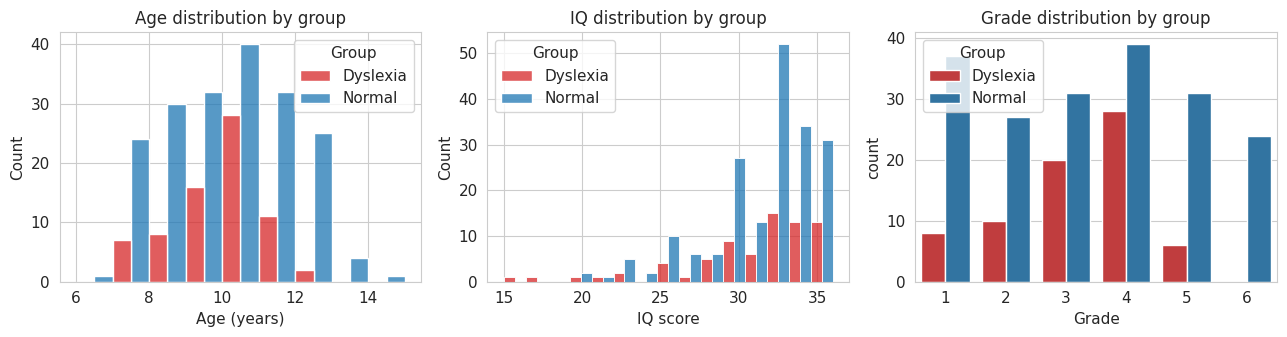

  Saved: ./figures/eda_eyetracking.png


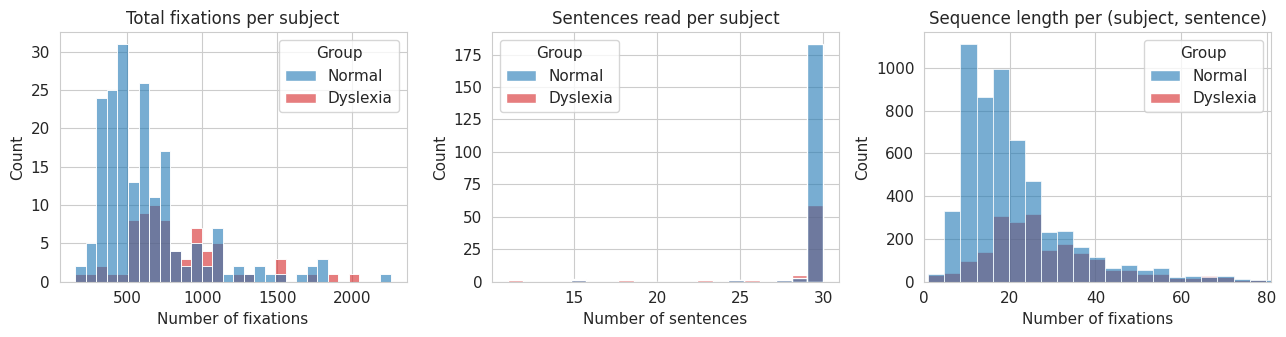

In [59]:
table, p_vals = dataset_summary_table(labels, fix)
eda_figure_demographics(labels)
eda_figure_eyetracking(fix, labels)

## 4. Сводная таблица всех моделей

Поправь словарь `model_results` под имена переменных в твоём ноутбуке.

In [67]:
def build_model_results_dict(catboost_ablation, gine_results, transformer_results,
                              gat_with_socdem, gat_no_socdem):
    """Унифицирует все результаты в один dict {model_name: result_dict}."""
    out = {
        'CatBoost (demo only)':   catboost_ablation['demo'],
        'CatBoost (eye only)':    catboost_ablation['eye'],
        'CatBoost (eye + demo)':  catboost_ablation['all'],
        'GINE (eye only)':        gine_results,
        'Transformer (eye only)': transformer_results,
        'GAT (eye only)':         gat_no_socdem,
        'GAT (eye + socdem)':     gat_with_socdem,
    }
    return out


def model_comparison_table(model_results, metrics=None):
    """Таблица: модель × метрика → 'mean ± std', с пометкой best по каждой метрике."""
    if metrics is None:
        metrics = ['auc', 'balanced_acc', 'f1_macro', 'recall_dyslexia', 'specificity']

    rows = []
    for name, res in model_results.items():
        row = {'Model': name}
        for m in metrics:
            vals = [f[m] for f in res['folds']
                    if m in f and not (isinstance(f[m], float) and np.isnan(f[m]))]
            if vals:
                row[m] = (float(np.mean(vals)), float(np.std(vals)))
            else:
                row[m] = (np.nan, np.nan)
        rows.append(row)

    # Найти лучшее значение по каждой метрике (для выделения)
    best_idx_per_metric = {}
    for m in metrics:
        means = [r[m][0] for r in rows]
        best_idx_per_metric[m] = int(np.argmax(means))

    # Форматирование
    display_rows = []
    for i, r in enumerate(rows):
        d = {'Model': r['Model']}
        for m in metrics:
            mean, std = r[m]
            cell = f"{mean:.3f} ± {std:.3f}"
            if i == best_idx_per_metric[m]:
                cell = f"**{cell}**"
            d[m] = cell
        display_rows.append(d)

    table = pd.DataFrame(display_rows)
    print("=" * 100)
    print("MODEL COMPARISON TABLE (best per column in **bold**, mean ± std over 5 folds)")
    print("=" * 100)
    print(table.to_string(index=False))
    return table, rows

## 5. Wilcoxon signed-rank: попарные сравнения моделей

In [50]:
def pairwise_wilcoxon(model_results, metric='auc', correction='bh'):
    """
    Pairwise Wilcoxon signed-rank на fold-level metric.

    Параметры:
      correction: 'bh' (Benjamini-Hochberg FDR, default) — мягкая, оставляет мощность.
                  'holm' — Family-Wise Error Rate, очень консервативная.
                  None — без коррекции, использовать только p_raw.

    ⚠ ВАЖНО: при n=5 фолдах минимально возможное p-value у Wilcoxon = 2/2^5 = 0.0625.
    То есть даже идеальная разница (все 5 фолдов GAT > CatBoost) даст p=0.0625,
    что > 0.05. Holm-коррекция на 21 пару делает почти все p_corrected=1.0.

    Решения:
      (а) использовать correction='bh' (BH FDR) — мягче;
      (б) использовать correction=None и смотреть p_raw;
      (в) запустить repeated CV (3-5 сидов × 5 фолдов = 15-25 точек) — это даёт
          реальную мощность для Wilcoxon. Это правильный путь для пейпера.
    """
    from scipy.stats import binomtest
    names = list(model_results.keys())
    fold_vals = {n: np.array([f[metric] for f in r['folds']])
                 for n, r in model_results.items()}
    n_folds = len(next(iter(fold_vals.values())))
    if n_folds < 6:
        print(f"  ⚠ n_folds={n_folds}: Wilcoxon min p-value = {2 / 2**n_folds:.4f} — "
              "low statistical power. Consider repeated CV (см. ниже).")

    pairs = list(combinations(names, 2))
    raw_results = []
    for a, b in pairs:
        va, vb = fold_vals[a], fold_vals[b]
        diff = va - vb
        if np.allclose(diff, 0):
            stat, p = float('nan'), 1.0
        else:
            try:
                stat, p = wilcoxon(va, vb)
            except ValueError:
                n_pos = int((diff > 0).sum()); n_total = int((diff != 0).sum())
                p = binomtest(n_pos, n_total, p=0.5).pvalue
                stat = float('nan')
        raw_results.append({
            'model_A': a, 'model_B': b,
            'mean_A': float(va.mean()), 'mean_B': float(vb.mean()),
            'diff_AB': float((va - vb).mean()),
            'W': stat, 'p_raw': float(p),
        })

    df = pd.DataFrame(raw_results).sort_values('p_raw').reset_index(drop=True)
    n = len(df)

    if correction == 'holm':
        df['p_corr'] = (df['p_raw'].values * (n - np.arange(n))).clip(max=1.0)
        df['p_corr'] = df['p_corr'].cummax()
        corr_label = 'Holm-Bonferroni (FWER)'
    elif correction == 'bh':
        # Benjamini-Hochberg FDR
        df['p_corr'] = (df['p_raw'].values * n / (np.arange(n) + 1)).clip(max=1.0)
        df['p_corr'] = df['p_corr'][::-1].cummin()[::-1]
        corr_label = 'Benjamini-Hochberg (FDR)'
    else:
        df['p_corr'] = df['p_raw']
        corr_label = 'no correction'

    df['sig_0.05'] = df['p_corr'] < 0.05

    print("=" * 100)
    print(f"PAIRWISE WILCOXON SIGNED-RANK on fold-level {metric} ({corr_label})")
    print("=" * 100)
    print(df.to_string(index=False))
    return df

## 7. Визуализация: AUC по моделям, error bars

In [51]:
def plot_model_comparison(model_results, metric='auc', save=True):
    names = list(model_results.keys())
    means = [np.mean([f[metric] for f in r['folds']]) for r in model_results.values()]
    stds  = [np.std([f[metric] for f in r['folds']])  for r in model_results.values()]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = ['#999999' if 'demo only' in n else
              '#1f77b4' if 'CatBoost' in n else
              '#2ca02c' if 'GINE' in n else
              '#ff7f0e' if 'Transformer' in n else
              '#d62728' for n in names]
    bars = ax.barh(names, means, xerr=stds, color=colors,
                   edgecolor='black', linewidth=0.5, alpha=0.85, capsize=4)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
    ax.set_xlabel(f"{metric} (mean ± std over 5 folds)")
    ax.set_xlim(0.4, 1.0)
    ax.set_title(f"Model comparison — {metric}")
    for bar, m, s in zip(bars, means, stds):
        ax.text(m + s + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{m:.3f}", va='center', fontsize=9)
    plt.tight_layout()
    if save:
        path = os.path.join(FIG_DIR, f"model_comparison_{metric}.png")
        fig.savefig(path)
        print(f"  Saved: {path}")
    plt.show()

## 8. Permutation summary table — для секции "Sanity checks" пейпера

In [61]:
def permutation_summary_table(perm_results_dict):
    """
    perm_results_dict: {'CatBoost': perm_df, 'GINE': perm_aucs_np, 'GAT': perm_aucs_np}
    Каждое значение — массив или DataFrame с колонкой 'auc' / список AUC.
    """
    rows = []
    for name, vals in perm_results_dict.items():
        if isinstance(vals, pd.DataFrame):
            arr = vals['auc'].values
        else:
            arr = np.asarray(vals)
        rows.append({
            'Model': name,
            'N permutations': len(arr),
            'Mean AUC (perm)': float(arr.mean()),
            'Std AUC (perm)': float(arr.std()),
            'Max AUC (perm)': float(arr.max()),
        })
    table = pd.DataFrame(rows)
    print("=" * 80)
    print("PERMUTATION TEST RESULTS (label-shuffled; expected AUC ≈ 0.5)")
    print("=" * 80)
    print(table.to_string(index=False))
    return table

In [64]:
perm_summary = permutation_summary_table({
    'CatBoost (all features)': perm_df,            # DataFrame от permutation_test
    'GAT (eye only)':          np.array([0.458, 0.396, 0.553]),  # вручную из вывода
})

PERMUTATION TEST RESULTS (label-shuffled; expected AUC ≈ 0.5)
                  Model  N permutations  Mean AUC (perm)  Std AUC (perm)  Max AUC (perm)
CatBoost (all features)              10          0.49972        0.046907        0.559244
         GAT (eye only)               3          0.46900        0.064565        0.553000


In [65]:
def repeated_cv(cv_func, n_seeds=3, base_seed=42, label='', **cv_kwargs):
    """Запускает cv_func с разными seeds, объединяет folds."""
    print(f"\n{'#' * 60}\n# REPEATED CV: {label} × {n_seeds} seeds\n{'#' * 60}")
    all_folds = []
    for s in range(n_seeds):
        seed = base_seed + s * 1000
        print(f"\n--- seed {s+1}/{n_seeds} (={seed}) ---")
        cv_kwargs['seed'] = seed
        res = cv_func(**cv_kwargs)
        all_folds.extend(res['folds'])
    return {'folds': all_folds, 'summary': aggregate_folds(all_folds), 'n_seeds': n_seeds}


def run_all_repeated(fix, labels, subj_df, sent_len, n_seeds=3, base_seed=42):
    """Прогоняет все 5 моделей. Возвращает model_results готовый для Wilcoxon."""
    eye_cols = [c for c in subj_df.columns
                if c not in ('SubjectID', 'label', 'Age', 'Sex', 'IQ', 'Grade')]
    demo_cols = ['Age', 'Sex', 'IQ', 'Grade']

    return {
        'CatBoost (demo only)':   repeated_cv(run_catboost_cv, n_seeds, base_seed,
                                              label='CatBoost demo',
                                              features_df=subj_df, feature_cols=demo_cols,
                                              n_folds=5, verbose=False),
        'CatBoost (eye only)':    repeated_cv(run_catboost_cv, n_seeds, base_seed,
                                              label='CatBoost eye',
                                              features_df=subj_df, feature_cols=eye_cols,
                                              n_folds=5, verbose=False),
        'CatBoost (eye + demo)':  repeated_cv(run_catboost_cv, n_seeds, base_seed,
                                              label='CatBoost all',
                                              features_df=subj_df, feature_cols=eye_cols + demo_cols,
                                              n_folds=5, verbose=False),
        'GINE (eye only)':        repeated_cv(run_gine_cv, n_seeds, base_seed,
                                              label='GINE',
                                              fix=fix, labels=labels, sent_len=sent_len,
                                              n_folds=5, epochs=60, patience=15),
        'Transformer (eye only)': repeated_cv(run_transformer_cv, n_seeds, base_seed,
                                              label='Transformer',
                                              fix=fix, labels=labels, sent_len=sent_len,
                                              n_folds=5, epochs=200, patience=20),
        'GAT (eye only)':         repeated_cv(run_gat_cv_v2, n_seeds, base_seed,
                                              label='GAT eye-only',
                                              fix=fix, labels=labels, use_socdem=False,
                                              n_folds=5, epochs=80, patience=20),
        'GAT (eye + socdem)':     repeated_cv(run_gat_cv_v2, n_seeds, base_seed,
                                              label='GAT eye+socdem',
                                              fix=fix, labels=labels, use_socdem=True,
                                              n_folds=5, epochs=80, patience=20),
    }

In [66]:
model_results = run_all_repeated(fix, labels, subj_df, sent_len, n_seeds=3)

# После завершения — те же функции из Части 5, но на 15 точках вместо 5:
comp_table, _ = model_comparison_table(model_results)
wilcoxon_auc = pairwise_wilcoxon(model_results, metric='auc')
wilcoxon_bal = pairwise_wilcoxon(model_results, metric='balanced_acc')


############################################################
# REPEATED CV: CatBoost demo × 3 seeds
############################################################

--- seed 1/3 (=42) ---

--- seed 2/3 (=1042) ---

--- seed 3/3 (=2042) ---

############################################################
# REPEATED CV: CatBoost eye × 3 seeds
############################################################

--- seed 1/3 (=42) ---

--- seed 2/3 (=1042) ---

--- seed 3/3 (=2042) ---

############################################################
# REPEATED CV: CatBoost all × 3 seeds
############################################################

--- seed 1/3 (=42) ---

--- seed 2/3 (=1042) ---

--- seed 3/3 (=2042) ---

############################################################
# REPEATED CV: GINE × 3 seeds
############################################################

--- seed 1/3 (=42) ---
Building graphs...
Built 7443 graphs (skipped 278)
Subjects with graphs: 261 (pos=72, neg=189)

--- Fold 1/5 --

NameError: name 'model_comparison_table' is not defined

In [68]:
comp_table, _ = model_comparison_table(model_results)
wilcoxon_auc = pairwise_wilcoxon(model_results, metric='auc')
wilcoxon_bal = pairwise_wilcoxon(model_results, metric='balanced_acc')

MODEL COMPARISON TABLE (best per column in **bold**, mean ± std over 5 folds)
                 Model               auc      balanced_acc          f1_macro   recall_dyslexia       specificity
  CatBoost (demo only)     0.641 ± 0.056     0.614 ± 0.069     0.560 ± 0.065     0.641 ± 0.247     0.587 ± 0.177
   CatBoost (eye only)     0.879 ± 0.041     0.783 ± 0.046     0.752 ± 0.049     0.776 ± 0.156     0.790 ± 0.115
 CatBoost (eye + demo)     0.905 ± 0.057     0.817 ± 0.059     0.797 ± 0.080     0.793 ± 0.114     0.840 ± 0.139
       GINE (eye only)     0.826 ± 0.057     0.751 ± 0.057     0.710 ± 0.066     0.777 ± 0.146     0.725 ± 0.121
Transformer (eye only)     0.761 ± 0.076     0.686 ± 0.087     0.654 ± 0.071     0.645 ± 0.229     0.727 ± 0.125
        GAT (eye only)     0.918 ± 0.045     0.842 ± 0.059     0.810 ± 0.072     0.864 ± 0.099     0.820 ± 0.107
    GAT (eye + socdem) **0.943 ± 0.032** **0.872 ± 0.040** **0.850 ± 0.037** **0.869 ± 0.118** **0.875 ± 0.075**
PAIRWISE WILCOXON 

In [54]:
def collect_roc_data(fix, labels, subj_df, sent_len, seed=42):
    """Один прогон каждой модели → results с probs для ROC/PR."""
    eye_cols = [c for c in subj_df.columns
                if c not in ('SubjectID', 'label', 'Age', 'Sex', 'IQ', 'Grade')]
    demo_cols = ['Age', 'Sex', 'IQ', 'Grade']

    print("=" * 50, "\nCatBoost (eye + demo)\n", "=" * 50)
    cb_all = run_catboost_cv(subj_df, eye_cols + demo_cols, n_folds=5, seed=seed, verbose=False)

    print("=" * 50, "\nGINE\n", "=" * 50)
    gine = run_gine_cv(fix, labels, sent_len, n_folds=5, epochs=60, patience=15, seed=seed)

    print("=" * 50, "\nTransformer\n", "=" * 50)
    transformer = run_transformer_cv(fix, labels, sent_len, n_folds=5, epochs=200,
                                      patience=20, batch_subjects=8, seed=seed)

    print("=" * 50, "\nGAT (eye only)\n", "=" * 50)
    gat_eye = run_gat_cv_v2(fix, labels, use_socdem=False, n_folds=5,
                             epochs=80, patience=20, seed=seed)

    print("=" * 50, "\nGAT (eye + socdem)\n", "=" * 50)
    gat_all = run_gat_cv_v2(fix, labels, use_socdem=True, n_folds=5,
                             epochs=80, patience=20, seed=seed)

    return {
        'CatBoost (eye+demo)':    cb_all,
        'GINE (eye)':             gine,
        'Transformer (eye)':      transformer,
        'GAT (eye only)':         gat_eye,
        'GAT (eye + socdem)':     gat_all,
    }

In [55]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

def plot_roc_pr_grid(model_results, save_path="figures/roc_pr.png"):
    """
    ROC и PR в одной фигуре (2 subplots).
    Каждая модель: mean curve + ±1 std band по фолдам.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(model_results))))

    # Общий FPR / Recall grid для интерполяции
    mean_fpr = np.linspace(0, 1, 200)
    mean_recall = np.linspace(0, 1, 200)

    for i, (name, res) in enumerate(model_results.items()):
        tprs, aucs = [], []
        precisions, aps = [], []
        for fold in res['folds']:
            y_t = fold['y_test_true']; y_p = fold['y_test_prob']
            # ROC
            fpr, tpr, _ = roc_curve(y_t, y_p)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(auc(fpr, tpr))
            # PR
            prec, rec, _ = precision_recall_curve(y_t, y_p)
            # PR обычно интерполируется по recall: prec(recall_target)
            prec_interp = np.interp(mean_recall, rec[::-1], prec[::-1])
            precisions.append(prec_interp)
            aps.append(average_precision_score(y_t, y_p))

        mean_tpr = np.mean(tprs, axis=0); std_tpr = np.std(tprs, axis=0)
        mean_prec = np.mean(precisions, axis=0); std_prec = np.std(precisions, axis=0)
        mean_auc = np.mean(aucs); std_auc = np.std(aucs)
        mean_ap = np.mean(aps); std_ap = np.std(aps)

        c = colors[i]
        ax_roc.plot(mean_fpr, mean_tpr, color=c, lw=2,
                    label=f"{name} (AUC={mean_auc:.3f}±{std_auc:.3f})")
        ax_roc.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0),
                            np.minimum(mean_tpr + std_tpr, 1), color=c, alpha=0.15)
        ax_pr.plot(mean_recall, mean_prec, color=c, lw=2,
                   label=f"{name} (AP={mean_ap:.3f}±{std_ap:.3f})")
        ax_pr.fill_between(mean_recall, np.maximum(mean_prec - std_prec, 0),
                           np.minimum(mean_prec + std_prec, 1), color=c, alpha=0.15)

    # Diagonal для ROC
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
    ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)
    ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC curves (mean ± 1 std over 5 folds)')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)

    # Baseline для PR: prevalence положительного класса
    prev = np.mean([f['y_test_true'].mean() for f in next(iter(model_results.values()))['folds']])
    ax_pr.axhline(prev, color='k', linestyle='--', alpha=0.4,
                  label=f'Chance (prevalence={prev:.2f})')
    ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02)
    ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Precision-Recall curves (mean ± 1 std over 5 folds)')
    ax_pr.legend(loc='lower left', fontsize=9)
    ax_pr.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()

CatBoost (eye + demo)
GINE
Building graphs...
Built 7443 graphs (skipped 278)
Subjects with graphs: 261 (pos=72, neg=189)

--- Fold 1/5 ---
  Subjects: train=176, val=32, test=53
  Graphs:   train=5010, val=926, test=1507
    early stop at epoch 25 (best val AUC=0.981)
  fold 1: bal_acc=0.736  recall_dys=0.867  spec=0.605  f1_macro=0.667  AUC=0.833  thr=0.48

--- Fold 2/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5059, val=924, test=1460
    early stop at epoch 42 (best val AUC=0.768)
  fold 2: bal_acc=0.812  recall_dys=0.867  spec=0.757  f1_macro=0.769  AUC=0.905  thr=0.46

--- Fold 3/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5043, val=907, test=1493
    early stop at epoch 49 (best val AUC=0.855)
  fold 3: bal_acc=0.771  recall_dys=0.857  spec=0.684  f1_macro=0.710  AUC=0.805  thr=0.30

--- Fold 4/5 ---
  Subjects: train=177, val=32, test=52
  Graphs:   train=5043, val=922, test=1478
    early stop at epoch 16 (best val AUC=0.841)
  fold 4: bal

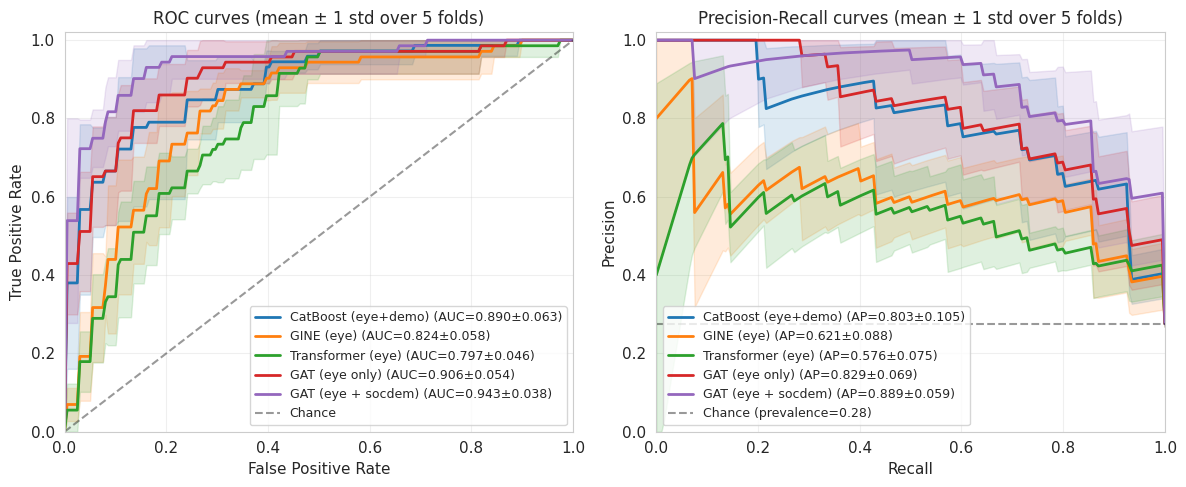

In [60]:
roc_results = collect_roc_data(fix, labels, subj_df, sent_len, seed=42)
plot_roc_pr_grid(roc_results, save_path="figures/roc_pr.png")

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def run_sklearn_cv(features_df, feature_cols, model_factory, n_folds=5,
                   seed=SEED, threshold_metric='balanced_accuracy', verbose=True):
    """
    Тот же шаблон что у run_catboost_cv: внешний 5-fold по субъектам,
    train/val/test, порог на val, метрики на test.

    model_factory — callable () -> sklearn estimator (со StandardScaler внутри
    если нужен). Должна возвращать СВЕЖИЙ estimator на каждом вызове.
    """
    set_global_seed(seed)
    subj_ids = features_df['SubjectID'].values
    y_all = features_df['label'].values
    splits = make_subject_cv_splits(subj_ids, y_all, n_folds=n_folds, seed=seed)
    fold_metrics = []
    for fold_i, (train_subj, val_subj, test_subj) in enumerate(splits, 1):
        tr = features_df[features_df['SubjectID'].isin(train_subj)]
        va = features_df[features_df['SubjectID'].isin(val_subj)]
        te = features_df[features_df['SubjectID'].isin(test_subj)]
        X_tr, y_tr = tr[feature_cols].values, tr['label'].values
        X_va, y_va = va[feature_cols].values, va['label'].values
        X_te, y_te = te[feature_cols].values, te['label'].values

        model = model_factory()
        model.fit(X_tr, y_tr)
        val_prob = model.predict_proba(X_va)[:, 1]
        best_thr = pick_threshold(y_va, val_prob, metric=threshold_metric)
        test_prob = model.predict_proba(X_te)[:, 1]
        test_pred = (test_prob >= best_thr).astype(int)
        m = compute_metrics(y_te, test_pred, test_prob)
        m['threshold'] = best_thr
        m['y_test_true'] = np.asarray(y_te).astype(int)
        m['y_test_prob'] = np.asarray(test_prob, dtype=float)
        fold_metrics.append(m)
        if verbose:
            print(f"  fold {fold_i}: AUC={m['auc']:.3f}  "
                  f"bal_acc={m['balanced_acc']:.3f}  "
                  f"recall_dys={m['recall_dyslexia']:.3f}  "
                  f"spec={m['specificity']:.3f}  thr={best_thr:.2f}")
    return {'folds': fold_metrics, 'summary': aggregate_folds(fold_metrics)}

In [70]:
def make_logreg():
    # StandardScaler важен для LR с регуляризацией
    return Pipeline([
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=2000,
                                   random_state=SEED, C=1.0)),
    ])


def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight='balanced', random_state=SEED, n_jobs=-1,
    )


def make_svm():
    # SVC + probability=True требует калибровки внутри — медленнее но корректно
    return Pipeline([
        ('scale', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced',
                    probability=True, random_state=SEED, C=1.0, gamma='scale')),
    ])

In [71]:
eye_cols = [c for c in subj_df.columns
            if c not in ('SubjectID', 'label', 'Age', 'Sex', 'IQ', 'Grade')]
demo_cols = ['Age', 'Sex', 'IQ', 'Grade']
all_cols = eye_cols + demo_cols

print("=" * 60, "\nLogistic Regression (eye + demo)\n", "=" * 60)
logreg_results = run_sklearn_cv(subj_df, all_cols, make_logreg, n_folds=5, seed=SEED)
print_cv_summary(logreg_results['summary'], "LR eye+demo")

print("=" * 60, "\nRandom Forest (eye + demo)\n", "=" * 60)
rf_results = run_sklearn_cv(subj_df, all_cols, make_rf, n_folds=5, seed=SEED)
print_cv_summary(rf_results['summary'], "RF eye+demo")

print("=" * 60, "\nSVM RBF (eye + demo)\n", "=" * 60)
svm_results = run_sklearn_cv(subj_df, all_cols, make_svm, n_folds=5, seed=SEED)
print_cv_summary(svm_results['summary'], "SVM eye+demo")

Logistic Regression (eye + demo)
  fold 1: AUC=0.847  bal_acc=0.749  recall_dys=0.867  spec=0.632  thr=0.22
  fold 2: AUC=0.977  bal_acc=0.855  recall_dys=1.000  spec=0.711  thr=0.28
  fold 3: AUC=0.788  bal_acc=0.699  recall_dys=0.714  spec=0.684  thr=0.32
  fold 4: AUC=0.964  bal_acc=0.859  recall_dys=0.929  spec=0.789  thr=0.30
  fold 5: AUC=0.926  bal_acc=0.893  recall_dys=0.867  spec=0.919  thr=0.14

=== LR eye+demo ===
  accuracy              : 0.7819 ± 0.0800
  balanced_acc          : 0.8111 ± 0.0739
  recall_dyslexia       : 0.8752 ± 0.0943
  specificity           : 0.7469 ± 0.1000
  precision_dyslexia    : 0.5855 ± 0.1275
  f1_dyslexia           : 0.6948 ± 0.0987
  f1_macro              : 0.7621 ± 0.0820
  auc                   : 0.9006 ± 0.0724
Random Forest (eye + demo)
  fold 1: AUC=0.928  bal_acc=0.861  recall_dys=0.800  spec=0.921  thr=0.44
  fold 2: AUC=0.947  bal_acc=0.727  recall_dys=0.929  spec=0.526  thr=0.18
  fold 3: AUC=0.791  bal_acc=0.686  recall_dys=0.714  spec

In [72]:
def shap_catboost(features_df, feature_cols, n_folds=5, seed=SEED, top_n=15,
                  save_path="figures/shap_catboost.png"):
    """
    Прогоняет CatBoost на 5 фолдах, на каждом считает SHAP на test, агрегирует
    mean |SHAP| по всем фичам, рисует top_n bar chart.
    """
    set_global_seed(seed)
    from catboost import Pool

    subj_ids = features_df['SubjectID'].values
    y_all = features_df['label'].values
    splits = make_subject_cv_splits(subj_ids, y_all, n_folds=n_folds, seed=seed)

    all_shap_abs = []  # list of [n_test_subj, n_features] arrays
    for fold_i, (train_subj, val_subj, test_subj) in enumerate(splits, 1):
        tr = features_df[features_df['SubjectID'].isin(train_subj)]
        va = features_df[features_df['SubjectID'].isin(val_subj)]
        te = features_df[features_df['SubjectID'].isin(test_subj)]
        X_tr, y_tr = tr[feature_cols], tr['label']
        X_va, y_va = va[feature_cols], va['label']
        X_te,  _   = te[feature_cols], te['label']

        n_neg = int((y_tr == 0).sum()); n_pos = int((y_tr == 1).sum())
        pos_w = n_neg / max(n_pos, 1)
        model = CatBoostClassifier(
            class_weights=[1.0, pos_w], iterations=2000, learning_rate=0.03,
            depth=6, loss_function='Logloss', eval_metric='AUC',
            early_stopping_rounds=100, random_seed=seed, verbose=0,
        )
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)

        pool = Pool(X_te, label=te['label'].values)
        shap_vals = model.get_feature_importance(pool, type='ShapValues')
        # последний столбец = expected_value, отрезаем
        shap_feat = shap_vals[:, :-1]  # [n_test, n_features]
        all_shap_abs.append(np.abs(shap_feat))
        print(f"  fold {fold_i}: SHAP computed on {shap_feat.shape[0]} test subjects")

    # Конкатенируем по всем фолдам → mean |SHAP| на фичу
    stacked = np.vstack(all_shap_abs)
    mean_abs_shap = stacked.mean(axis=0)
    importance = pd.DataFrame({
        'feature': feature_cols,
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    # Plot top_n
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.3)))
    top = importance.head(top_n)[::-1]
    ax.barh(top['feature'], top['mean_abs_shap'], color='#1f77b4',
            edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Mean |SHAP value|  (contribution to prediction)')
    ax.set_title(f'CatBoost feature importance — top {top_n} '
                 f'(averaged over {n_folds} folds)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()
    return importance

In [73]:
# # SHAP для CatBoost на eye+demo фичах
# shap_importance = shap_catboost(subj_df, eye_cols + demo_cols, n_folds=5,
#                                  seed=SEED, top_n=15)
# print("\nTop-15 features by mean |SHAP|:")
# print(shap_importance.head(15))

  fold 1: SHAP computed on 53 test subjects
  fold 2: SHAP computed on 52 test subjects
  fold 3: SHAP computed on 52 test subjects
  fold 4: SHAP computed on 52 test subjects
  fold 5: SHAP computed on 52 test subjects
  Saved: figures/shap_catboost.png


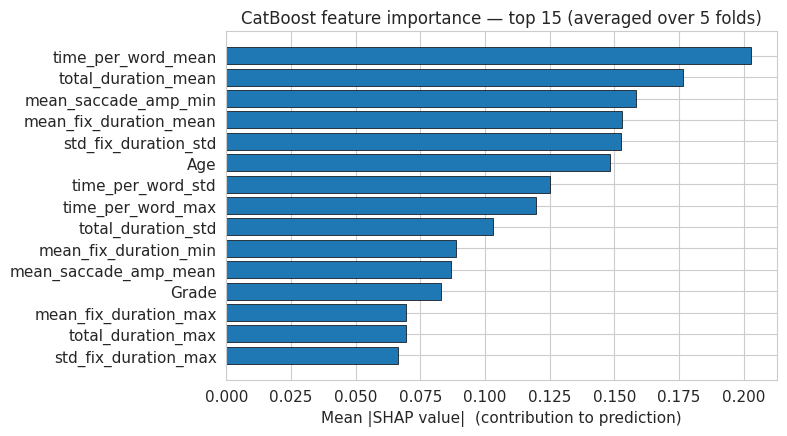


Top-15 features by mean |SHAP|:
                   feature  mean_abs_shap
0       time_per_word_mean       0.202769
1      total_duration_mean       0.176644
2     mean_saccade_amp_min       0.158507
3   mean_fix_duration_mean       0.152936
4     std_fix_duration_std       0.152690
5                      Age       0.148464
6        time_per_word_std       0.125325
7        time_per_word_max       0.119569
8       total_duration_std       0.103201
9    mean_fix_duration_min       0.088791
10   mean_saccade_amp_mean       0.086887
11                   Grade       0.082907
12   mean_fix_duration_max       0.069442
13      total_duration_max       0.069369
14    std_fix_duration_max       0.066256


In [74]:
# SHAP для CatBoost на eye+demo фичах
shap_importance = shap_catboost(subj_df, eye_cols + demo_cols, n_folds=5,
                                 seed=SEED, top_n=15)
print("\nTop-15 features by mean |SHAP|:")
print(shap_importance.head(15))

In [82]:
extended_model_results = {
    'Logistic Regression':    logreg_results,
    'Random Forest':          rf_results,
    'SVM (RBF)':              svm_results,
    'CatBoost (eye+demo)':    results['all'],
    'GINE (eye)':             gine_results,
    'Transformer (eye)':      transformer_results,
    'GAT (eye only)':         gat_no_socdem,
    'GAT (eye + socdem)':     gat_with_socdem,
}
comp_table, _ = model_comparison_table(extended_model_results)
pairwise_wilcoxon(extended_model_results, metric='auc')

MODEL COMPARISON TABLE (best per column in **bold**, mean ± std over 5 folds)
              Model               auc      balanced_acc          f1_macro   recall_dyslexia       specificity
Logistic Regression     0.901 ± 0.072     0.811 ± 0.074     0.762 ± 0.082     0.875 ± 0.094     0.747 ± 0.100
      Random Forest     0.895 ± 0.065     0.771 ± 0.060     0.744 ± 0.093     0.764 ± 0.096     0.778 ± 0.162
          SVM (RBF)     0.889 ± 0.075     0.793 ± 0.071     0.764 ± 0.090     0.791 ± 0.124     0.794 ± 0.145
CatBoost (eye+demo)     0.890 ± 0.063     0.785 ± 0.053     0.753 ± 0.089     0.792 ± 0.134     0.778 ± 0.177
         GINE (eye)     0.826 ± 0.050     0.765 ± 0.027     0.708 ± 0.031     0.847 ± 0.071     0.683 ± 0.064
  Transformer (eye)     0.797 ± 0.046     0.716 ± 0.069     0.678 ± 0.061     0.680 ± 0.258     0.752 ± 0.145
     GAT (eye only)     0.906 ± 0.051     0.806 ± 0.067     0.755 ± 0.078     0.872 ± 0.139     0.739 ± 0.139
 GAT (eye + socdem) **0.941 ± 0.040** **0.

,model_A,model_B,mean_A,mean_B,diff_AB,W,p_raw,p_corr,sig_0.05
0,GAT (eye only),GAT (eye + socdem),0.905582,0.941091,-0.035508,0.0,0.0625,0.218750,False
1,Transformer (eye),GAT (eye + socdem),0.796760,0.941091,-0.144330,0.0,0.0625,0.218750,False
2,Random Forest,Transformer (eye),0.895013,0.796760,0.098253,0.0,0.0625,0.218750,False
3,GINE (eye),GAT (eye only),0.826391,0.905582,-0.079191,0.0,0.0625,0.218750,False
4,GINE (eye),GAT (eye + socdem),0.826391,0.941091,-0.114700,0.0,0.0625,0.218750,False
5,CatBoost (eye+demo),Transformer (eye),0.889532,0.796760,0.092772,0.0,0.0625,0.218750,False
6,Transformer (eye),GAT (eye only),0.796760,0.905582,-0.108822,0.0,0.0625,0.218750,False
7,Logistic Regression,Transformer (eye),0.900564,0.796760,0.103803,0.0,0.0625,0.218750,False
8,SVM (RBF),Transformer (eye),0.888701,0.796760,0.091941,1.0,0.1250,0.388889,False
9,Logistic Regression,GINE (eye),0.900564,0.826391,0.074173,2.0,0.1875,0.525000,False


In [83]:
!unzip -q data.zip -d etdd70

In [8]:
import re
import os, glob

ETDD_DATA_DIR = "/home/jupyter/project/etdd70/data"
ETDD_TASK = 'T4_Meaningful_Text'


def load_etdd70_fixations(data_dir=ETDD_DATA_DIR, task=ETDD_TASK):
    """
    Грузит все Subject_{sid}_{task}_fixations.csv → один DataFrame в нашем формате.

    Возвращает: SubjectID, Sentence_ID (=trialid), FIX_X, FIX_Y, FIX_DURATION,
    отсортированный хронологически.
    """
    pattern = os.path.join(data_dir, f"Subject_*_{task}_fixations.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        pattern = os.path.join(data_dir, "**", f"Subject_*_{task}_fixations.csv")
        files = sorted(glob.glob(pattern, recursive=True))

    print(f"Found {len(files)} fixation files for task '{task}'")
    if not files:
        raise FileNotFoundError(
            f"No files matching 'Subject_*_{task}_fixations.csv' in {data_dir}"
        )

    sid_re = re.compile(r'Subject_(\d+)_')

    dfs = []
    for f in files:
        m = sid_re.search(os.path.basename(f))
        if not m:
            continue
        sid = int(m.group(1))
        df = pd.read_csv(f)
        df['_sid_from_filename'] = sid
        dfs.append(df)

    fix = pd.concat(dfs, ignore_index=True)
    print(f"  Total: {len(fix):,} fixations from {fix['_sid_from_filename'].nunique()} subjects")
    print(f"  Columns in raw file: {fix.columns.tolist()}")

    sid_col = 'sid' if 'sid' in fix.columns else '_sid_from_filename'

    if 'start_ms' in fix.columns and 'trialid' in fix.columns:
        fix = fix.sort_values([sid_col, 'trialid', 'start_ms']).reset_index(drop=True)

    out = pd.DataFrame({
        'SubjectID': fix[sid_col].astype(str),
        'Sentence_ID': fix['trialid'].astype(int) if 'trialid' in fix.columns
                        else np.zeros(len(fix), dtype=int),
        'FIX_X': fix['fix_x'].astype(float),
        'FIX_Y': fix['fix_y'].astype(float),
        'FIX_DURATION': fix['duration_ms'].astype(float),
    })
    return out


def load_etdd70_labels(labels_path=None, data_dir=ETDD_DATA_DIR):
    """
    Грузит dyslexia_class_label.csv.

    После загрузки печатает реальные имена колонок — если они не sid/label,
    функция вернёт сырой DataFrame и попросит поправить колонки вручную.
    """
    if labels_path is None:
        candidates = []
        candidates += glob.glob(os.path.join(data_dir, '..', 'dyslexia_class_label*.csv'))
        candidates += glob.glob(os.path.join(data_dir, 'dyslexia_class_label*.csv'))
        candidates += glob.glob(os.path.join(data_dir, '..', '..', 'dyslexia_class_label*.csv'))
        if not candidates:
            # Recursive search
            base = os.path.dirname(data_dir) or data_dir
            candidates = glob.glob(os.path.join(base, '**', 'dyslexia_class_label*.csv'),
                                    recursive=True)
        if not candidates:
            raise FileNotFoundError(
                "dyslexia_class_label.csv не найден. Укажи путь явно через "
                "load_etdd70_labels(labels_path='...')"
            )
        labels_path = candidates[0]
        print(f"Using labels file: {labels_path}")

    df = pd.read_csv(labels_path)
    print(f"Labels file columns: {df.columns.tolist()}")
    print(df.head())

    sid_col = None
    for c in ['sid', 'subject_id', 'participant_id', 'subject', 'id']:
        if c in df.columns:
            sid_col = c
            break

    label_col = None
    for c in ['label', 'dyslexia_class', 'dyslexia', 'class', 'group']:
        if c in df.columns:
            label_col = c
            break

    if sid_col is None or label_col is None:
        print(f"\n⚠ Автодетект не сработал. Колонки: {df.columns.tolist()}")
        print("Возвращаю сырой DataFrame. Поправь функцию вручную:")
        print("  out['SubjectID'] = df['ИМЯ_КОЛОНКИ'].astype(str)")
        print("  out['label']     = df['ИМЯ_КОЛОНКИ'].apply(...)")
        return df

    print(f"\nDetected: sid_col='{sid_col}', label_col='{label_col}'")
    print(f"Label values: {df[label_col].unique()}")

    # Преобразуем label к {0, 1}
    def to_binary(x):
        s = str(x).lower().strip()
        if s in ('1', 'dyslexic', 'dys', 'true', 'positive', 'yes'):
            return 1
        if s in ('0', 'non-dyslexic', 'non', 'norm', 'normal', 'false', 'negative', 'no'):
            return 0
        # На крайний случай: числовое значение
        return int(float(x))

    out = pd.DataFrame({
        'SubjectID': df[sid_col].astype(str),
        'label': df[label_col].apply(to_binary).astype(int),
    })
    # Dummy demo cols чтобы compute_subject_level не падал
    for c in ['Sex', 'Age', 'IQ', 'Grade']:
        out[c] = 0

    print(f"  Total: {len(out)} subjects "
          f"(pos={int(out['label'].sum())}, neg={int((out['label']==0).sum())})")
    return out

In [11]:
# 1) Грузим fixations + labels
etdd_fix    = load_etdd70_fixations(ETDD_DATA_DIR, task='T4_Meaningful_Text')
etdd_labels = load_etdd70_labels(
    labels_path="/home/jupyter/project/etdd70/dyslexia_class_label.csv"
)
# 2) Проверка
print(etdd_fix.head())
print(etdd_labels.head())
print(f"\nSubjects in fixations: {etdd_fix['SubjectID'].nunique()}")
print(f"Subjects in labels:    {len(etdd_labels)}")
# Они должны пересекаться:
common = set(etdd_fix['SubjectID']) & set(etdd_labels['SubjectID'])
print(f"Common: {len(common)}")

Found 70 fixation files for task 'T4_Meaningful_Text'
  Total: 15,964 fixations from 70 subjects
  Columns in raw file: ['id', 'task', 'sid', 'eye', 'stimfile', 'trialid', 'start_ms', 'end_ms', 'duration_ms', 'fix_x', 'fix_y', 'orig_fix_x', 'orig_fix_y', 'disp_x', 'disp_y', 'aoi_subline', 'aoi_line', '_sid_from_filename']
Labels file columns: ['subject_id', 'class_id', 'label']
   subject_id  class_id         label
0        1003         0  non-dyslexic
1        1016         0  non-dyslexic
2        1019         0  non-dyslexic
3        1033         0  non-dyslexic
4        1040         0  non-dyslexic

Detected: sid_col='subject_id', label_col='label'
Label values: ['non-dyslexic' 'dyslexic']
  Total: 70 subjects (pos=35, neg=35)
  SubjectID  Sentence_ID     FIX_X  FIX_Y  FIX_DURATION
0      1003          158  150.5075  198.5       175.926
1      1003          158  371.6975  198.5       168.035
2      1003          158  305.8250  198.5       299.944
3      1003          158  381.1700  

In [13]:
def compute_sentence_level_word_agnostic(fix):
    """Признаки для каждой пары (subject, sentence) без использования Word_Number."""
    rows = []
    for (subj, sent), g in fix.groupby(['SubjectID', 'Sentence_ID'], sort=False):
        if len(g) < 2:
            continue
        x = g['FIX_X'].values
        y = g['FIX_Y'].values
        d = g['FIX_DURATION'].values

        dx = np.diff(x); dy = np.diff(y)
        sacc = np.sqrt(dx**2 + dy**2)
        # Регрессия = саккада справа налево в чтении слева направо (dx<0)
        # Это валидно для всех LTR-языков (русский, чешский)
        regs = int((dx < 0).sum())

        if np.unique(x).size > 1:
            sr = float(np.corrcoef(np.arange(len(x)), x)[0, 1])
        else:
            sr = 0.0
        total_dist = float(sacc.sum()) if len(sacc) else 1.0

        rows.append({
            'SubjectID': subj, 'Sentence_ID': sent,
            'fix_count': len(g),
            'total_duration': float(d.sum()),
            'mean_fix_duration': float(d.mean()),
            'std_fix_duration': float(d.std(ddof=0)),
            'mean_saccade_amp': float(sacc.mean()) if len(sacc) else 0.0,
            'max_saccade_amp': float(sacc.max()) if len(sacc) else 0.0,
            'regression_count': regs,
            'regression_ratio': regs / max(1, len(dx)),
            'scan_regularity': sr if not np.isnan(sr) else 0.0,
            'time_per_distance': float(d.sum() / max(total_dist, 1.0)),  # вместо time_per_word
        })
    return pd.DataFrame(rows)


def compute_subject_level_word_agnostic(sentence_df, labels):
    """Агрегация sentence-level на уровень субъекта (без demo features)."""
    metric_cols = [c for c in sentence_df.columns if c not in ('SubjectID', 'Sentence_ID')]
    agg = sentence_df.groupby('SubjectID')[metric_cols].agg(['mean', 'std', 'max', 'min'])
    agg.columns = [f'{a}_{b}' for a, b in agg.columns]
    agg = agg.reset_index()
    out = agg.merge(labels[['SubjectID', 'label']], on='SubjectID', how='inner')
    return out

In [14]:
def prepare_both_datasets(our_fix, our_labels, etdd_fix, etdd_labels):
    """Возвращает (our_subj_df, etdd_subj_df, shared_features)."""
    # Наш датасет
    our_sent = compute_sentence_level_word_agnostic(our_fix)
    our_subj = compute_subject_level_word_agnostic(our_sent, our_labels)

    # ETDD70
    etdd_sent = compute_sentence_level_word_agnostic(etdd_fix)
    etdd_subj = compute_subject_level_word_agnostic(etdd_sent, etdd_labels)

    # SubjectID к строкам для совместимости
    our_subj['SubjectID'] = our_subj['SubjectID'].astype(str)
    etdd_subj['SubjectID'] = etdd_subj['SubjectID'].astype(str)

    shared_features = [c for c in our_subj.columns
                       if c not in ('SubjectID', 'label')
                       and c in etdd_subj.columns]

    print(f"\n=== DATASET COMPARISON ===")
    print(f"Ours:    {len(our_subj)} subjects "
          f"(pos={int(our_subj['label'].sum())}, neg={int((our_subj['label']==0).sum())})")
    print(f"ETDD70:  {len(etdd_subj)} subjects "
          f"(pos={int(etdd_subj['label'].sum())}, neg={int((etdd_subj['label']==0).sum())})")
    print(f"Shared features: {len(shared_features)}")

    return our_subj, etdd_subj, shared_features

In [15]:
def fit_and_eval(X_tr, y_tr, X_te, y_te, seed=SEED, val_size=0.15):
    """Обучает CatBoost на train, оценивает на test. Порог подбирается на val
    (15% от train, стратифицированно)."""
    X_tr2, X_va, y_tr2, y_va = train_test_split(
        X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=seed
    )
    n_neg = int((y_tr2 == 0).sum()); n_pos = int((y_tr2 == 1).sum())
    pos_w = n_neg / max(n_pos, 1)
    model = CatBoostClassifier(
        class_weights=[1.0, pos_w], iterations=2000, learning_rate=0.03,
        depth=6, loss_function='Logloss', eval_metric='AUC',
        early_stopping_rounds=100, random_seed=seed, verbose=0,
    )
    model.fit(X_tr2, y_tr2, eval_set=(X_va, y_va), use_best_model=True)
    val_prob = model.predict_proba(X_va)[:, 1]
    thr = pick_threshold(y_va, val_prob, metric='balanced_accuracy')
    te_prob = model.predict_proba(X_te)[:, 1]
    te_pred = (te_prob >= thr).astype(int)
    m = compute_metrics(y_te, te_pred, te_prob)
    m['threshold'] = thr
    return m


def cross_dataset_eval(our_subj, etdd_subj, shared_features, seed=SEED):
    print("\n" + "=" * 70)
    print("CROSS-DATASET EVALUATION (word-agnostic features)")
    print(f"Features ({len(shared_features)}): {shared_features}")
    print("=" * 70)

    # (A) Train ours, test ETDD70
    print("\n(A) Train: ours (RU, 261 subj), Test: ETDD70 (CZ, 70 subj)")
    X_tr = our_subj[shared_features].values
    y_tr = our_subj['label'].values
    X_te = etdd_subj[shared_features].values
    y_te = etdd_subj['label'].values
    m_A = fit_and_eval(X_tr, y_tr, X_te, y_te, seed=seed)
    for k in ('auc', 'balanced_acc', 'recall_dyslexia', 'specificity', 'f1_macro'):
        print(f"    {k:18s}: {m_A[k]:.3f}")

    # (B) Train ETDD70, test ours
    print("\n(B) Train: ETDD70 (CZ, 70 subj), Test: ours (RU, 261 subj)")
    X_tr = etdd_subj[shared_features].values
    y_tr = etdd_subj['label'].values
    X_te = our_subj[shared_features].values
    y_te = our_subj['label'].values
    m_B = fit_and_eval(X_tr, y_tr, X_te, y_te, seed=seed)
    for k in ('auc', 'balanced_acc', 'recall_dyslexia', 'specificity', 'f1_macro'):
        print(f"    {k:18s}: {m_B[k]:.3f}")

    # (C) Контроль — наш 5-fold CV на этих же word-agnostic фичах
    print("\n(C) Control: 5-fold CV on ours-only with same word-agnostic features")
    res_C = run_catboost_cv(our_subj, shared_features, n_folds=5, seed=seed, verbose=True)
    print_cv_summary(res_C['summary'], "Ours-only word-agnostic CV")

    # (D) Контроль — их 5-fold CV на их данных
    print("\n(D) Control: 5-fold CV on ETDD70 with same features")
    # ETDD70 balanced (35/35), но subjects всего 70 — 5-fold даст ~14 test
    res_D = run_catboost_cv(etdd_subj, shared_features, n_folds=5, seed=seed, verbose=True)
    print_cv_summary(res_D['summary'], "ETDD70-only CV")

    return {'A_our_to_etdd': m_A, 'B_etdd_to_our': m_B,
            'C_our_cv': res_C, 'D_etdd_cv': res_D}

In [16]:
def plot_feature_distributions(our_subj, etdd_subj, features, n_max=8,
                                save_path="figures/etdd_distributions.png"):
    """Гистограммы топ-N фич в обоих датасетах по группам."""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    features = features[:n_max]
    n = len(features)
    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5.5))
    if n == 1:
        axes = axes.reshape(2, 1)
    palette = {1: '#d62728', 0: '#1f77b4'}
    for j, feat in enumerate(features):
        for i, (name, df) in enumerate([('Ours (RU)', our_subj), ('ETDD70 (CZ)', etdd_subj)]):
            ax = axes[i, j]
            for lbl in [0, 1]:
                vals = df[df['label'] == lbl][feat].dropna().values
                ax.hist(vals, bins=20, alpha=0.6, color=palette[lbl],
                        label='Dys' if lbl == 1 else 'Norm')
            if j == 0:
                ax.set_ylabel(name, fontsize=10)
            if i == 0:
                ax.set_title(feat, fontsize=9)
            if i == 0 and j == 0:
                ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()

Found 70 fixation files for task 'T4_Meaningful_Text'
  Total: 15,964 fixations from 70 subjects
  Columns in raw file: ['id', 'task', 'sid', 'eye', 'stimfile', 'trialid', 'start_ms', 'end_ms', 'duration_ms', 'fix_x', 'fix_y', 'orig_fix_x', 'orig_fix_y', 'disp_x', 'disp_y', 'aoi_subline', 'aoi_line', '_sid_from_filename']
Labels file columns: ['subject_id', 'class_id', 'label']
   subject_id  class_id         label
0        1003         0  non-dyslexic
1        1016         0  non-dyslexic
2        1019         0  non-dyslexic
3        1033         0  non-dyslexic
4        1040         0  non-dyslexic

Detected: sid_col='subject_id', label_col='label'
Label values: ['non-dyslexic' 'dyslexic']
  Total: 70 subjects (pos=35, neg=35)

=== DATASET COMPARISON ===
Ours:    261 subjects (pos=72, neg=189)
ETDD70:  70 subjects (pos=35, neg=35)
Shared features: 40

CROSS-DATASET EVALUATION (word-agnostic features)
Features (40): ['fix_count_mean', 'fix_count_std', 'fix_count_max', 'fix_count_min'

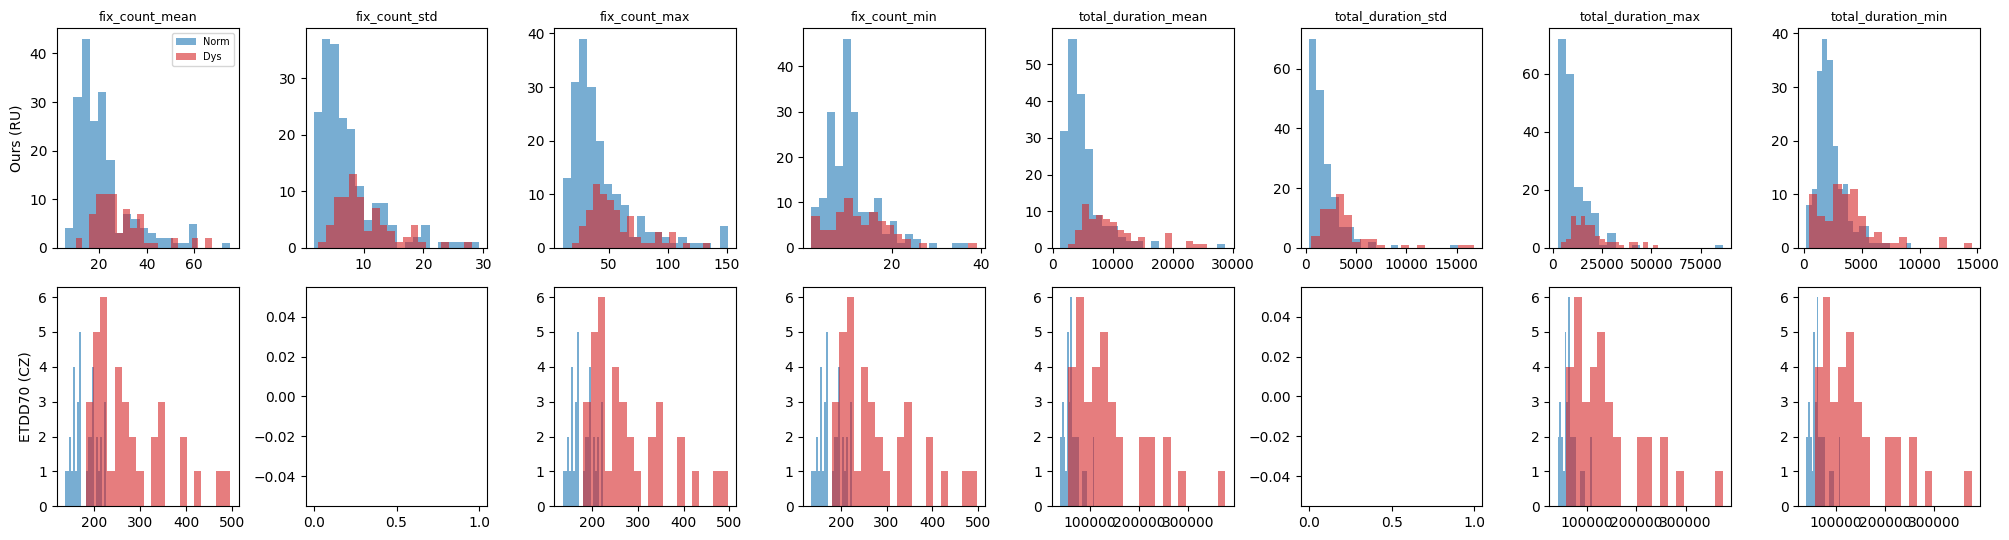

In [37]:
# Шаг 1: Загрузка ETDD70
etdd_fix    = load_etdd70_fixations(ETDD_DATA_DIR, task='T4_Meaningful_Text')
etdd_labels = load_etdd70_labels(
    labels_path="/home/jupyter/project/etdd70/dyslexia_class_label.csv"
)
# Шаг 2: Подготовка обоих датасетов с word-agnostic features
our_subj_wa, etdd_subj_wa, shared = prepare_both_datasets(
    fix, labels, etdd_fix, etdd_labels
)

# Шаг 3: Cross-dataset experiments (A, B, C, D)
cross_results = cross_dataset_eval(our_subj_wa, etdd_subj_wa, shared)

# Шаг 4: Визуализация распределений
plot_feature_distributions(our_subj_wa, etdd_subj_wa, shared, n_max=8)

In [38]:
from sklearn.preprocessing import StandardScaler


def fit_and_eval_scaled(X_tr, y_tr, X_te, y_te, seed=SEED, val_size=0.15):
    """Версия fit_and_eval с z-score scaler — фитится на train, применяется
    к train/val/test одинаково."""
    X_tr2, X_va, y_tr2, y_va = train_test_split(
        X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=seed
    )

    scaler = StandardScaler().fit(X_tr2)
    X_tr2 = scaler.transform(X_tr2)
    X_va = scaler.transform(X_va)
    X_te = scaler.transform(X_te)

    n_neg = int((y_tr2 == 0).sum()); n_pos = int((y_tr2 == 1).sum())
    pos_w = n_neg / max(n_pos, 1)
    model = CatBoostClassifier(
        class_weights=[1.0, pos_w], iterations=2000, learning_rate=0.03,
        depth=6, loss_function='Logloss', eval_metric='AUC',
        early_stopping_rounds=100, random_seed=seed, verbose=0,
    )
    model.fit(X_tr2, y_tr2, eval_set=(X_va, y_va), use_best_model=True)

    val_prob = model.predict_proba(X_va)[:, 1]
    thr = pick_threshold(y_va, val_prob, metric='balanced_accuracy')
    te_prob = model.predict_proba(X_te)[:, 1]
    te_pred = (te_prob >= thr).astype(int)
    m = compute_metrics(y_te, te_pred, te_prob)
    m['threshold'] = thr
    m['val_prob_range'] = (float(val_prob.min()), float(val_prob.max()))
    m['te_prob_range'] = (float(te_prob.min()), float(te_prob.max()))
    return m


def cross_dataset_eval_scaled(our_subj, etdd_subj, shared_features, seed=SEED):
    """Версия cross_dataset_eval со скейлингом."""
    print("\n" + "=" * 70)
    print("CROSS-DATASET EVALUATION (z-score scaled, word-agnostic features)")
    print("=" * 70)

    results = {}

    # (A) train ours, test ETDD70
    print("\n(A) Train: ours (RU, 261 subj), Test: ETDD70 (CZ, 70 subj)")
    m_A = fit_and_eval_scaled(
        our_subj[shared_features].values, our_subj['label'].values,
        etdd_subj[shared_features].values, etdd_subj['label'].values, seed=seed,
    )
    for k in ('auc', 'balanced_acc', 'recall_dyslexia', 'specificity', 'f1_macro'):
        print(f"    {k:18s}: {m_A[k]:.3f}")
    print(f"    threshold: {m_A['threshold']:.3f}")
    print(f"    val prob range: [{m_A['val_prob_range'][0]:.3f}, {m_A['val_prob_range'][1]:.3f}]")
    print(f"    test prob range: [{m_A['te_prob_range'][0]:.3f}, {m_A['te_prob_range'][1]:.3f}]")
    results['A_our_to_etdd'] = m_A

    # (B) train ETDD70, test ours
    print("\n(B) Train: ETDD70 (CZ, 70 subj), Test: ours (RU, 261 subj)")
    m_B = fit_and_eval_scaled(
        etdd_subj[shared_features].values, etdd_subj['label'].values,
        our_subj[shared_features].values, our_subj['label'].values, seed=seed,
    )
    for k in ('auc', 'balanced_acc', 'recall_dyslexia', 'specificity', 'f1_macro'):
        print(f"    {k:18s}: {m_B[k]:.3f}")
    print(f"    threshold: {m_B['threshold']:.3f}")
    print(f"    val prob range: [{m_B['val_prob_range'][0]:.3f}, {m_B['val_prob_range'][1]:.3f}]")
    print(f"    test prob range: [{m_B['te_prob_range'][0]:.3f}, {m_B['te_prob_range'][1]:.3f}]")
    results['B_etdd_to_our'] = m_B

    return results


In [39]:
cross_results_scaled = cross_dataset_eval_scaled(our_subj_wa, etdd_subj_wa, shared) 


CROSS-DATASET EVALUATION (z-score scaled, word-agnostic features)

(A) Train: ours (RU, 261 subj), Test: ETDD70 (CZ, 70 subj)
    auc               : 0.744
    balanced_acc      : 0.500
    recall_dyslexia   : 1.000
    specificity       : 0.000
    f1_macro          : 0.333
    threshold: 0.300
    val prob range: [0.012, 0.962]
    test prob range: [0.373, 0.686]

(B) Train: ETDD70 (CZ, 70 subj), Test: ours (RU, 261 subj)
    auc               : 0.675
    balanced_acc      : 0.500
    recall_dyslexia   : 0.000
    specificity       : 1.000
    f1_macro          : 0.420
    threshold: 0.524
    val prob range: [0.397, 0.598]
    test prob range: [0.457, 0.516]


In [40]:
def combined_cv(our_subj, etdd_subj, shared_features, seed=SEED, n_folds=5):
    print("\n(E) Combined CV on ours + ETDD70 (331 subjects total)")
    # Различаем SubjectID между датасетами префиксами чтобы не было коллизий
    o = our_subj[['SubjectID', 'label'] + shared_features].copy()
    e = etdd_subj[['SubjectID', 'label'] + shared_features].copy()
    o['SubjectID'] = 'RU_' + o['SubjectID'].astype(str)
    e['SubjectID'] = 'CZ_' + e['SubjectID'].astype(str)
    combined = pd.concat([o, e], ignore_index=True)
    print(f"  Total: {len(combined)} subjects "
          f"(pos={int(combined['label'].sum())}, neg={int((combined['label']==0).sum())})")
    res = run_catboost_cv(combined, shared_features, n_folds=n_folds, seed=seed, verbose=True)
    print_cv_summary(res['summary'], "Combined RU+CZ CV")
    return res

In [42]:
combined_results = combined_cv(our_subj_wa, etdd_subj_wa, shared)


(E) Combined CV on ours + ETDD70 (331 subjects total)
  Total: 331 subjects (pos=107, neg=224)
  fold 1: bal_acc=0.796  recall_dys=0.682  spec=0.911  f1_macro=0.807  AUC=0.890  thr=0.58
  fold 2: bal_acc=0.843  recall_dys=0.952  spec=0.733  f1_macro=0.795  AUC=0.916  thr=0.30
  fold 3: bal_acc=0.838  recall_dys=0.810  spec=0.867  f1_macro=0.830  AUC=0.908  thr=0.58
  fold 4: bal_acc=0.716  recall_dys=0.476  spec=0.956  f1_macro=0.737  AUC=0.906  thr=0.72
  fold 5: bal_acc=0.784  recall_dys=0.636  spec=0.932  f1_macro=0.800  AUC=0.848  thr=0.56

=== Combined RU+CZ CV ===
  accuracy              : 0.8247 ± 0.0185
  balanced_acc          : 0.7955 ± 0.0459
  recall_dyslexia       : 0.7113 ± 0.1610
  specificity           : 0.8797 ± 0.0788
  precision_dyslexia    : 0.7621 ± 0.0761
  f1_dyslexia           : 0.7166 ± 0.0584
  f1_macro              : 0.7937 ± 0.0305
  auc                   : 0.8936 ± 0.0243


In [43]:
def fit_and_eval_perset_norm(X_tr, y_tr, X_te, y_te, seed=SEED, val_size=0.15):
    """Каждый датасет нормализуется по СВОЕЙ статистике перед обучением/прогнозом."""
    # Per-dataset scalers (фитятся на полных датасетах, не на split'е)
    scaler_tr = StandardScaler().fit(X_tr)
    scaler_te = StandardScaler().fit(X_te)
    X_tr = scaler_tr.transform(X_tr)
    X_te = scaler_te.transform(X_te)

    X_tr2, X_va, y_tr2, y_va = train_test_split(
        X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=seed
    )
    n_neg = int((y_tr2 == 0).sum()); n_pos = int((y_tr2 == 1).sum())
    pos_w = n_neg / max(n_pos, 1)
    model = CatBoostClassifier(
        class_weights=[1.0, pos_w], iterations=2000, learning_rate=0.03,
        depth=6, loss_function='Logloss', eval_metric='AUC',
        early_stopping_rounds=100, random_seed=seed, verbose=0,
    )
    model.fit(X_tr2, y_tr2, eval_set=(X_va, y_va), use_best_model=True)
    val_prob = model.predict_proba(X_va)[:, 1]
    thr = pick_threshold(y_va, val_prob, metric='balanced_accuracy')
    te_prob = model.predict_proba(X_te)[:, 1]
    te_pred = (te_prob >= thr).astype(int)
    m = compute_metrics(y_te, te_pred, te_prob)
    m['threshold'] = thr
    return m


def cross_dataset_eval_perset(our_subj, etdd_subj, shared_features, seed=SEED):
    print("\n=== Per-dataset normalized cross-dataset ===")
    print("\n(A') RU → CZ, per-dataset normalized:")
    m_A = fit_and_eval_perset_norm(
        our_subj[shared_features].values, our_subj['label'].values,
        etdd_subj[shared_features].values, etdd_subj['label'].values, seed=seed,
    )
    for k in ('auc', 'balanced_acc', 'recall_dyslexia', 'specificity', 'f1_macro'):
        print(f"    {k:18s}: {m_A[k]:.3f}")
    print(f"    threshold: {m_A['threshold']:.3f}")

    print("\n(B') CZ → RU, per-dataset normalized:")
    m_B = fit_and_eval_perset_norm(
        etdd_subj[shared_features].values, etdd_subj['label'].values,
        our_subj[shared_features].values, our_subj['label'].values, seed=seed,
    )
    for k in ('auc', 'balanced_acc', 'recall_dyslexia', 'specificity', 'f1_macro'):
        print(f"    {k:18s}: {m_B[k]:.3f}")
    print(f"    threshold: {m_B['threshold']:.3f}")
    return {'A_perset': m_A, 'B_perset': m_B}

# Запуск:
cross_results_perset = cross_dataset_eval_perset(our_subj_wa, etdd_subj_wa, shared)


=== Per-dataset normalized cross-dataset ===

(A') RU → CZ, per-dataset normalized:
    auc               : 0.881
    balanced_acc      : 0.800
    recall_dyslexia   : 0.743
    specificity       : 0.857
    f1_macro          : 0.799
    threshold: 0.300

(B') CZ → RU, per-dataset normalized:
    auc               : 0.780
    balanced_acc      : 0.700
    recall_dyslexia   : 0.639
    specificity       : 0.762
    f1_macro          : 0.683
    threshold: 0.524
